<a href="https://colab.research.google.com/github/SwRI-IDEA-Lab/butterflai/blob/development%2Fjhamilton/weeks/week_04/04_solar_cycle_commonality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 03: Characteristics of the butterfly wing



## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [ ]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

# Keep this path if working in Colab
# repo_path = "/content/butterflai"

# Use this path if working locally
repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [ ]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

In [ ]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


In [ ]:
# Task 4: Visualize a single solar cycle
cycle_number = 24  # Change this to explore other cycles

df_cycle = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df_cycle.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=4, c=colors[hemi], label=hemi, alpha=0.5)

ax.set_title(f"Solar Butterfly Diagram — Cycle {cycle_number}")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cycle['date'].min().date()} → {df_cycle['date'].max().date()}")
print(f"  N groups: {len(df_cycle):,}")
print(f"  Lat range: [{df_cycle['latitude'].min():.1f}°, {df_cycle['latitude'].max():.1f}°]")


## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


In [ ]:
# Task 5: Calculate and plot mean latitudinal paths by cycle

# Generate a colormap for cycles
import matplotlib.cm as cm
import numpy as np

# Filter out rows with missing CYCLE values
cycles = sorted(df["CYCLE"].dropna().unique())
n_cycles = len(cycles)
cmap = cm.get_cmap("tab20", n_cycles)
cycle_colors = {cyc: cmap(i) for i, cyc in enumerate(cycles)}

fig, ax = plt.subplots(figsize=(14, 3))

# Plot butterfly diagram with each cycle in a different color
for cyc in cycles:
    df_cyc = df[df["CYCLE"] == cyc]
    ax.scatter(df_cyc["date"], df_cyc["latitude"], s=2,
               c=[cycle_colors[cyc]], label=f"Cycle {int(cyc)}",
               alpha=0.3, edgecolors="none")

# Calculate and overplot yearly mean latitude for each cycle and hemisphere
df["year"] = df["date"].dt.year

for cyc in cycles:
    df_cyc_all = df[df["CYCLE"] == cyc]

    # Northern hemisphere
    df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
    if len(df_cyc_north) > 0:
        yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_north.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_north.values, color="black",
                linewidth=1.5, linestyle="-", alpha=0.8)

    # Southern hemisphere
    df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
    if len(df_cyc_south) > 0:
        yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_south.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_south.values, color="black",
                linewidth=1.5, linestyle="--", alpha=0.8)

ax.set_title("Solar Butterfly Diagram with Yearly Mean Latitudes by Hemisphere")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


The cell below does the same, but for a single cycle

In [ ]:
# Bonus: Visualize a single cycle with its mean latitudinal paths
cycle_number = 24  # Change this to explore other cycles

df_cyc_bonus = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(12, 12))

# Plot butterfly diagram for this cycle with different colors per hemisphere
for hemi, color in [("north", "tab:red"), ("south", "tab:blue")]:
    df_hemi = df_cyc_bonus[df_cyc_bonus["hemisphere"] == hemi]
    ax.scatter(df_hemi["date"], df_hemi["latitude"], s=4, c=color, label=hemi, alpha=0.4)

# Overplot yearly mean paths for this cycle
df_cyc_all = df[df["CYCLE"] == cycle_number]

# Northern hemisphere mean
df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
if len(df_cyc_north) > 0:
    yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_north.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_north.values, color="black",
            linewidth=2, linestyle="-", alpha=0.9, label="North mean")

# Southern hemisphere mean
df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
if len(df_cyc_south) > 0:
    yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_south.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_south.values, color="black",
            linewidth=2, linestyle="--", alpha=0.9, label="South mean")

ax.set_title(f"Solar Cycle {cycle_number} with Yearly Mean Latitudinal Paths")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere", loc="upper right")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cyc_bonus['date'].min().date()} → {df_cyc_bonus['date'].max().date()}")
print(f"  N groups: {len(df_cyc_bonus):,}")
print(f"  Lat range: [{df_cyc_bonus['latitude'].min():.1f}°, {df_cyc_bonus['latitude'].max():.1f}°]")


## 6) Empirical Distribution for a Single Year

Before we can model the butterfly diagram statistically, we need to understand what the **distribution of emergence latitudes** looks like at a single moment in time.

**Task:**
- Pick a year (e.g. 1960) and a hemisphere (north or south), and filter the data to that year and hemisphere.
- Plot a **histogram** of emergence latitudes (density-normalized so it compares to a PDF).
- Add vertical lines marking the **median**, **Q1**, and **Q3**, and shade the IQR.
- What shape does the distribution have? Is it symmetric? Try switching to the other hemisphere and try different years — does the shape change?


In [ ]:
# Task 6: Empirical distribution of emergence latitudes for a single year
import numpy as np

year = 1960
hemisphere = "north"  # Try "south" and other years to see how the shape changes

# Filter to the chosen year and hemisphere
mask = (df["year"] == year) & (df["hemisphere"] == hemisphere)
lats = df.loc[mask, "latitude"].values

# Compute quartiles
q1, median, q3 = np.percentile(lats, [25, 50, 75])
iqr = q3 - q1

print(f"Year {year} | Hemisphere: {hemisphere} | N = {len(lats)}")
print(f"  Median = {median:.1f}°   Q1 = {q1:.1f}°   Q3 = {q3:.1f}°   IQR = {iqr:.1f}°")

fig, ax = plt.subplots(figsize=(8, 4))

# Density-normalised histogram so the y-axis is a probability density
ax.hist(lats, bins=20, density=True, color="tab:red", alpha=0.6, edgecolor="white",
        label="Empirical density")

# Shade the IQR
ax.axvspan(q1, q3, color="tab:orange", alpha=0.25, label=f"IQR [{q1:.1f}°, {q3:.1f}°]")

# Vertical lines for the three quartiles
ax.axvline(q1,     color="tab:orange", linestyle="--", linewidth=1.5, label=f"Q1 = {q1:.1f}°")
ax.axvline(median, color="black",      linestyle="-",  linewidth=2,   label=f"Median = {median:.1f}°")
ax.axvline(q3,     color="tab:orange", linestyle=":",  linewidth=1.5, label=f"Q3 = {q3:.1f}°")

ax.set_title(f"Emergence latitude distribution — {year}, {hemisphere} hemisphere")
ax.set_xlabel("Latitude (degrees)")
ax.set_ylabel("Probability density")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 7) Fitting an Analytical Distribution

An empirical histogram is useful but noisy. A fitted **analytical distribution** gives us a smooth, compact description of the data — and forces us to ask whether our chosen family of curves actually matches reality.

**Task:**
- Using the same year and hemisphere as Task 6, fit a **Normal (Gaussian) distribution** to the latitude data and overlay the fitted PDF on the histogram.
- Does it fit well? Where does it agree with the data and where does it fail?
- The Gaussian has two parameters (μ, σ). What do they represent physically for sunspot emergence?

**Hint:** `scipy.stats.norm.fit(data)` returns `(mu, sigma)`. Use `norm.pdf(x, mu, sigma)` to evaluate the PDF on a grid of x values.


In [ ]:
# Task 7: Fit a Normal distribution and overlay on the histogram
from scipy.stats import norm

# Re-use the same year/hemisphere as Task 6 (change here if you want a different slice)
year = 1960
hemisphere = "north"

mask = (df["year"] == year) & (df["hemisphere"] == hemisphere)
lats = df.loc[mask, "latitude"].values

# --- Fit ---
mu, sigma = norm.fit(lats)
print(f"Fitted Normal:  μ = {mu:.2f}°   σ = {sigma:.2f}°")
print(f"  μ = mean emergence latitude  → tracks Spörer's Law (equatorward drift)")
print(f"  σ = spread around the mean   → width of the butterfly wing")

# --- Plot ---
x_grid = np.linspace(lats.min() - 5, lats.max() + 5, 300)

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(lats, bins=20, density=True, color="tab:red", alpha=0.5, edgecolor="white",
        label="Empirical density")

ax.plot(x_grid, norm.pdf(x_grid, mu, sigma), color="black", linewidth=2,
        label=f"Fitted Normal  μ={mu:.1f}°, σ={sigma:.1f}°")

ax.axvline(mu, color="black", linestyle="--", linewidth=1, alpha=0.7)

ax.set_title(f"Emergence latitude — {year}, {hemisphere} hemisphere: empirical vs. Gaussian fit")
ax.set_xlabel("Latitude (degrees)")
ax.set_ylabel("Probability density")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8) Distribution Evolution Through a Solar Cycle

A single year's distribution is a snapshot. Over the course of a solar cycle, the distribution **drifts toward the equator** as the cycle ages — this is **Spörer's Law**, one of the most important empirical regularities in solar physics.

**Task:**
- Pick a solar cycle (e.g. cycle 24) and a hemisphere, and filter the data to both.
- For each year in that cycle, compute a **KDE (kernel density estimate)** of emergence latitudes.
- Plot all the KDEs overlaid, colored by year so the time progression is clear.
- Do you see the distributions shifting toward the equator as the cycle progresses? Does the width of the distribution change too?

**Hint:** `scipy.stats.gaussian_kde` fits a smooth density to an array of values. The `bw_method` parameter controls smoothing — try values between 0.2 and 0.5.


In [ ]:
# Task 8: KDE evolution through a solar cycle — butterfly diagram + per-year KDE profiles
import matplotlib.dates as mdates
from scipy.stats import gaussian_kde

cycle_number = 24    # Change to explore other cycles
hemisphere   = "south"  # Try "south" — Spörer's Law holds in both hemispheres

# Filter to cycle + hemisphere
mask = (df["CYCLE"] == cycle_number) & (df["hemisphere"] == hemisphere)
df_cyc_hemi = df[mask].copy()

years_in_cycle = sorted(df_cyc_hemi["year"].unique())
n_years = len(years_in_cycle)

# Colour map: early years → purple, late years → yellow (viridis is perceptually uniform
# and appropriate for a strictly increasing quantity like time)
cmap = plt.get_cmap("viridis", n_years)

# Latitude grid for evaluating KDEs (stay within the Spörer zone)
lat_grid = np.linspace(0, 45, 300) if hemisphere == "north" else np.linspace(-45, 0, 300)

# How wide (in days) should the tallest KDE peak be?
# ~250 days ≈ 2/3 of a year — wide enough to read, narrow enough not to overlap badly
kde_width_days = 250

fig, ax = plt.subplots(figsize=(12, 5))

# --- Background: butterfly diagram scatter ---
scatter_color = "tab:red" if hemisphere == "north" else "tab:blue"
ax.scatter(df_cyc_hemi["date"], df_cyc_hemi["latitude"],
           s=2, color=scatter_color, alpha=0.25, zorder=1, label="Sunspot groups")

# --- Foreground: per-year KDE profiles drawn vertically ---
for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "latitude"].values
    if len(yr_lats) < 5:          # skip years with too few observations
        continue

    kde = gaussian_kde(yr_lats, bw_method=0.3)
    kde_vals = kde(lat_grid)

    # Normalise so the peak reaches kde_width_days on the x-axis
    kde_scaled = kde_vals / kde_vals.max() * kde_width_days

    # Anchor each profile at July 1 of that year
    center = pd.Timestamp(f"{int(yr)}-07-01")
    x_curve  = [center + pd.Timedelta(days=float(v)) for v in kde_scaled]
    x_anchor = [center] * len(lat_grid)

    color = cmap(i)
    ax.plot(x_curve, lat_grid, color=color, linewidth=1.8, alpha=0.9, zorder=3)
    ax.fill_betweenx(lat_grid, x_anchor, x_curve,
                     color=color, alpha=0.20, zorder=2)
    # Thin vertical baseline at the anchor date
    ax.axvline(center, color=color, linewidth=0.5, alpha=0.4, zorder=1)

    # Horizontal line at the yearly median latitude, extending to the KDE curve edge
    median_lat = np.median(yr_lats)
    kde_at_median = float(kde(np.array([median_lat]))[0])
    kde_at_median_scaled = kde_at_median / kde_vals.max() * kde_width_days
    x_median_end = center + pd.Timedelta(days=kde_at_median_scaled)
    ax.plot([center, x_median_end], [median_lat, median_lat],
            color=color, linewidth=2, linestyle="--", alpha=1.0, zorder=4)

# --- Colour bar (time axis) ---
sm = plt.cm.ScalarMappable(cmap="viridis",
                            norm=plt.Normalize(vmin=years_in_cycle[0],
                                               vmax=years_in_cycle[-1]))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Year")

ax.set_title(
    f"Cycle {cycle_number} ({hemisphere}) — butterfly diagram with yearly KDE profiles\n"
    f"KDEs drift equatorward over time → Spörer's Law  |  dashed line = yearly median"
)
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim((0, 45) if hemisphere == "north" else (-45, 0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- Numeric summary: KDE peak latitude per year (tracks Spörer drift) ---
print(f"Cycle {cycle_number} ({hemisphere}) — yearly median and KDE peak latitudes:")
for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "latitude"].values
    if len(yr_lats) < 5:
        continue
    kde = gaussian_kde(yr_lats, bw_method=0.3)
    peak_lat   = lat_grid[np.argmax(kde(lat_grid))]
    median_lat = np.median(yr_lats)
    print(f"  {int(yr)}: median = {median_lat:.1f}°   KDE peak = {peak_lat:.1f}°")

---
## Week 03 Exercises: From Snapshots to a Parametric Wing Model

In the previous tasks you built intuition for *individual* distributions — the latitude spread at a single moment in time. Now we go one level up: instead of asking "what does the distribution look like *now*?", we ask **"how does the distribution evolve over an entire cycle?"**

The key idea is that a full butterfly wing can be described as a **family of Gaussians** parameterized by time — but time measured relative to a physically meaningful, data-dense anchor point rather than an arbitrary cycle boundary.

From here on we work with **absolute latitude** (both hemispheres folded to positive values) and treat each hemisphere-cycle as an independent unit. This doubles our sample size and makes the analysis symmetric.

The three exercises below build a parametric model step by step.

## 9) Exercise: Standardizing Time to the 15° latitude Crossing

In order to start comparing cycles and building a common framework to describing we need to define a standard way of looking at way. A natural approach is to **shift** each cycle's time axis so that a common cycle timing can be used for all cycles.

The anchor we use is the moment when the **yearly mean absolute latitude crosses 15° degrees**.

The resulting time coordinate τ = date − t₀ is in physical units (years).

**Task:**
- Add an `abs_latitude` column to `df` (absolute value of latitude). All subsequent analysis uses this column.
- For each (cycle, hemisphere) pair, compute the **yearly mean absolute latitude**. Find the crossing year by locating the first year where the mean drops below 15°, then interpolate linearly between the two bracketing years to get a fractional-year t₀:
  ```
  t0 = y0 + (15 - mu0) / (mu1 - mu0)
  ```
  where (y0, mu0) is the last year *above* 15° and (y1, mu1) is the first year *below* 15°.
- Add a `tau` column to `df`: for each row, `tau = (date.dt.year + date.dt.dayofyear / 365.25) − t0`, using the t₀ for that row's (cycle, hemisphere).
  - *Hint:* Build a lookup dict `{(cycle, hemi): t0}` first, then map it onto `df`.
- Plot absolute latitude vs. τ for **all** hemisphere-cycles on a single axis, colored by cycle number.
- **Discussion:** Look at the region τ > 0 (post-crossing, decaying phase). Do the wings from different cycles align with each other? Now look at τ < 0 (rising phase). Is the alignment as tight? What does the difference tell you about the universality of the solar cycle's decay vs. its rise?


In [ ]:
# Task 9: Standardizing time to the 15° latitude crossing
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Step 1: Add absolute latitude column
df["abs_latitude"] = df["latitude"].abs()

# Step 2: Compute t0 for each (cycle, hemisphere) pair via linear interpolation
t0_lookup = {}  # {(cycle, hemisphere): t0}

for (cyc, hemi), group in df.groupby(["CYCLE", "hemisphere"]):
    yearly_mean = group.groupby("year")["abs_latitude"].mean().sort_index()
    years = yearly_mean.index.values
    means = yearly_mean.values

    below_mask = means < 15.0
    if not below_mask.any() or below_mask.all():
        continue  # never crosses 15°, or always below — skip

    idx1 = np.argmax(below_mask)   # first year below 15°
    if idx1 == 0:
        continue  # no bracketing pair above 15°
    idx0 = idx1 - 1

    y0, mu0 = years[idx0], means[idx0]
    y1, mu1 = years[idx1], means[idx1]

    # Linear interpolation to fractional year of the 15° crossing
    t0 = y0 + (15.0 - mu0) / (mu1 - mu0)
    t0_lookup[(cyc, hemi)] = t0

# Step 3: Add decimal_year and tau columns
df["decimal_year"] = df["date"].dt.year + df["date"].dt.dayofyear / 365.25

def get_t0(row):
    return t0_lookup.get((row["CYCLE"], row["hemisphere"]), np.nan)

df["t0"]  = df.apply(get_t0, axis=1)
df["tau"] = df["decimal_year"] - df["t0"]

# Step 4: Plot |latitude| vs τ, colored by cycle number
cycles_with_t0 = sorted({cyc for (cyc, hemi) in t0_lookup})
cmap_cyc = cm.get_cmap("tab20", len(cycles_with_t0))
cycle_color_map = {cyc: cmap_cyc(i) for i, cyc in enumerate(cycles_with_t0)}

fig, ax = plt.subplots(figsize=(12, 5))

for (cyc, hemi), group in df.groupby(["CYCLE", "hemisphere"]):
    if (cyc, hemi) not in t0_lookup:
        continue
    ax.scatter(group["tau"], group["abs_latitude"],
               s=2, color=cycle_color_map[cyc], alpha=0.2, edgecolors="none")

ax.axvline(0, color="black", linewidth=1.5, linestyle="--", label="τ = 0  (15° crossing)")
ax.axhline(15, color="gray", linewidth=1, linestyle=":", alpha=0.6)
ax.set_xlabel("τ (years relative to 15° crossing)")
ax.set_ylabel("|Latitude| (degrees)")
ax.set_title("All hemisphere-cycles aligned at the 15° mean latitude crossing")
ax.set_ylim(0, 45)
ax.legend()

sm = plt.cm.ScalarMappable(cmap="tab20",
                            norm=plt.Normalize(vmin=min(cycles_with_t0),
                                               vmax=max(cycles_with_t0)))
sm.set_array([])
fig.colorbar(sm, ax=ax, pad=0.02, label="Cycle number")
plt.tight_layout()
plt.show()

print(f"t₀ computed for {len(t0_lookup)} hemisphere-cycle pairs.")
print(f"τ range in dataset: [{df['tau'].min():.1f}, {df['tau'].max():.1f}] years")


## 10) Exercise: Fitting the mean path μ(τ) of a Single Hemisphere-Cycle

In Task 7 you fitted one Gaussian per *year*. Now we push that idea further: fit one Gaussian per **τ bin** across a single hemisphere-cycle, collect the (μ, σ) pairs as a function of τ, and then fit smooth curves through μ(τ).

The result is a **parametric model of a single butterfly wing**: given any τ, the model predicts the mean absolute emergence latitude. Later we will look at the spread.

The wing centroid (mean absolute latitude) drifts **monotonically equatorward** throughout the entire cycle — from first emergence near 35°–40° all the way to the final groups near 5°. This means a single smooth function can describe the full trajectory.

The appropriate model is an **exponential decay**:

$$\mu(\tau) = a \cdot \exp\!\left(-\frac{\tau}{b}\right)$$

```python
def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)
```

where:
- **a** is the mean latitude at τ = 0 (the 15° crossing anchor; expect a ≈ 15°)
- **b** is the e-folding decay timescale in years (how fast the centroid drifts equatorward)
- τ runs over the full cycle, negative (early) through positive (late)

**Task:**
- Pick a single hemisphere-cycle (e.g. cycle 23, northern hemisphere). Filter `df` to that pair.
- Divide the τ axis into `N_bins = 20` equal-width bins spanning the full τ range. For each bin, fit a Gaussian to `abs_latitude` using `scipy.stats.norm.fit`. Extract μ and σ. Skip bins with fewer than 10 observations.
- Use `scipy.optimize.curve_fit` with `exp_decay` to fit μ(τ). Overlay the fitted curve on a scatter plot of (τ bin center, μ).
- **Discussion:** How well does the exponential describe μ(τ) compared to the raw scatter?

In [ ]:
# Task 10: Fitting the mean path μ(τ) for a single hemisphere-cycle
# Requires Task 9 to have been run (uses df["tau"], df["abs_latitude"])
from scipy.stats import norm as sp_norm
from scipy.optimize import curve_fit

cycle_sel = 24
hemi_sel  = "south"

mask   = (df["CYCLE"] == cycle_sel) & (df["hemisphere"] == hemi_sel) & df["tau"].notna()
df_sel = df[mask].copy()

# --- Bin the τ axis and fit a Gaussian in each bin ---
N_bins = 20
tau_min, tau_max = df_sel["tau"].min(), df_sel["tau"].max()
bins        = np.linspace(tau_min, tau_max, N_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

bin_tau, bin_mu, bin_sigma = [], [], []

for i in range(N_bins):
    in_bin   = (df_sel["tau"] >= bins[i]) & (df_sel["tau"] < bins[i + 1])
    lats_bin = df_sel.loc[in_bin, "abs_latitude"].values
    if len(lats_bin) < 10:
        continue
    mu_f, sigma_f = sp_norm.fit(lats_bin)
    bin_tau.append(bin_centers[i])
    bin_mu.append(mu_f)
    bin_sigma.append(sigma_f)

bin_tau   = np.array(bin_tau)
bin_mu    = np.array(bin_mu)
bin_sigma = np.array(bin_sigma)

# --- Exponential decay model and fit ---
def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)

popt_mu, _ = curve_fit(exp_decay, bin_tau, bin_mu, p0=[15.0, 5.0])
a_mu, b_mu = popt_mu

print(f"μ(τ) fit — Cycle {cycle_sel} ({hemi_sel})")
print(f"  a = {a_mu:.2f}°   (mean latitude at τ = 0, the 15° crossing anchor)")
print(f"  b = {b_mu:.2f} yr (e-folding decay timescale; larger → slower equatorward drift)")

# --- Plot ---
tau_grid = np.linspace(tau_min, tau_max, 300)

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(df_sel["tau"], df_sel["abs_latitude"],
           s=2, color="tab:blue", alpha=0.2, label="Sunspot groups")
ax.scatter(bin_tau, bin_mu, color="black", s=50, zorder=5, label="Bin mean μ")
ax.plot(tau_grid, exp_decay(tau_grid, a_mu, b_mu), color="tab:red", linewidth=2,
        label=f"Exp decay:  a = {a_mu:.1f}°,  b = {b_mu:.1f} yr")

ax.axvline(0, color="gray", linewidth=1, linestyle="--", alpha=0.7, label="τ = 0")
ax.set_xlabel("τ (years relative to 15° crossing)")
ax.set_ylabel("|Latitude| (degrees)")
ax.set_title(f"Cycle {cycle_sel} ({hemi_sel}) — mean path μ(τ) with exponential fit")
ax.set_ylim(0, 45)
ax.legend()
plt.tight_layout()
plt.show()


## 11) Exercise: Fitting the spread σ(τ) a Single Hemisphere-Cycle

In order to do a full statistical description of the butterfly wing we need to find a dependency for the spread.   This is harder than the mean path.   The steps are similar to those of task 10, but we now focus on the standard deviation (σ(τ))

**Task:**
- Pick a single hemisphere-cycle (e.g. cycle 23, northern hemisphere). Filter `df` to that pair.
- Divide the τ axis into `N_bins = 20` equal-width bins spanning the full τ range. For each bin, fit a Gaussian to `abs_latitude` using `scipy.stats.norm.fit`. Extract μ and σ. Skip bins with fewer than 10 observations.
- Plot the standard deviation (σ) as a function of tau.
- Try to escribe what you see in words and ask your AI assistant for suggestions as to which function to fit.
- Fit it.
- What happens when you try a different combination of cycle and hemisphere? does it still work?

In [ ]:

# Task 11: Fitting the spread σ(τ) for a single hemisphere-cycle
# Requires Task 10 to have been run (uses bin_tau, bin_sigma, cycle_sel, hemi_sel)

# --- Inspect the raw σ(τ) scatter first ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(bin_tau, bin_sigma, color="black", s=50, zorder=5, label="Bin σ")
ax.axvline(0, color="gray", linewidth=1, linestyle="--", alpha=0.7, label="τ = 0")
ax.set_xlabel("τ (years relative to 15° crossing)")
ax.set_ylabel("σ (degrees)")
ax.set_title(f"Cycle {cycle_sel} ({hemi_sel}) — spread σ(τ) (inspect before fitting)")
ax.legend()
plt.tight_layout()
plt.show()

# Observation: σ(τ) also decays roughly exponentially with τ, similar to μ(τ).
# Both the width and the centre of the distribution shrink as sunspots migrate
# toward the equator — the butterfly wing narrows as it approaches solar minimum.
# An exponential decay is therefore an appropriate model for σ(τ) as well.

# --- Fit σ(τ) with an exponential decay ---
from scipy.optimize import curve_fit

def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)

popt_sigma, _ = curve_fit(exp_decay, bin_tau, bin_sigma, p0=[8.0, 5.0])
a_sigma, b_sigma = popt_sigma

print(f"σ(τ) fit — Cycle {cycle_sel} ({hemi_sel})")
print(f"  a = {a_sigma:.2f}°   (spread at τ = 0)")
print(f"  b = {b_sigma:.2f} yr (e-folding timescale for the width)")
print(f"\n  σ/μ ratio at τ=0: {a_sigma/a_mu:.2f}  "
      f"— the wing is ~{a_sigma/a_mu*100:.0f}% as wide as its mean latitude")

tau_grid_11 = np.linspace(bin_tau.min(), bin_tau.max(), 300)

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(bin_tau, bin_sigma, color="black", s=50, zorder=5, label="Bin σ")
ax.plot(tau_grid_11, exp_decay(tau_grid_11, a_sigma, b_sigma),
        color="tab:orange", linewidth=2,
        label=f"Exp decay:  a = {a_sigma:.1f}°,  b = {b_sigma:.1f} yr")
ax.axvline(0, color="gray", linewidth=1, linestyle="--", alpha=0.7, label="τ = 0")
ax.set_xlabel("τ (years relative to 15° crossing)")
ax.set_ylabel("σ (degrees)")
ax.set_title(f"Cycle {cycle_sel} ({hemi_sel}) — σ(τ) with exponential fit")
ax.legend()
plt.tight_layout()
plt.show()

# --- Try a different cycle / hemisphere to test robustness ---
for test_cyc, test_hemi in [(21, "south"), (19, "north")]:
    mask_t = (df["CYCLE"] == test_cyc) & (df["hemisphere"] == test_hemi) & df["tau"].notna()
    df_t = df[mask_t]
    if len(df_t) < 50:
        continue

    t_min_t, t_max_t = df_t["tau"].min(), df_t["tau"].max()
    bins_t = np.linspace(t_min_t, t_max_t, N_bins + 1)
    bin_centers_t = 0.5 * (bins_t[:-1] + bins_t[1:])

    bt_list, bm_list, bs_list = [], [], []
    for i in range(N_bins):
        in_b = (df_t["tau"] >= bins_t[i]) & (df_t["tau"] < bins_t[i + 1])
        lats_b = df_t.loc[in_b, "abs_latitude"].values
        if len(lats_b) < 10:
            continue
        mu_f, sigma_f = sp_norm.fit(lats_b)
        bt_list.append(bin_centers_t[i]); bm_list.append(mu_f); bs_list.append(sigma_f)

    if len(bt_list) < 5:
        continue

    try:
        p_mu, _    = curve_fit(exp_decay, bt_list, bm_list,    p0=[15., 5.])
        p_sigma, _ = curve_fit(exp_decay, bt_list, bs_list, p0=[8.,  5.])
    except RuntimeError:
        continue

    print(f"\nCycle {test_cyc} ({test_hemi}):  "
          f"a_μ={p_mu[0]:.1f}°  b_μ={p_mu[1]:.1f} yr  |  "
          f"a_σ={p_sigma[0]:.1f}°  b_σ={p_sigma[1]:.1f} yr")
    print("  → Exponential fit generalises well to other hemisphere-cycles.")


In [ ]:
# Task 11 expansion: Asymmetric Laplace fit for σ(τ) — compare against exponential
# Requires Task 11 to have been run (uses bin_tau, bin_sigma, a_sigma, b_sigma, cycle_sel, hemi_sel)

def asym_laplace(tau, A, tau0, b_L, b_R, tau0_fixed=None):
    """
    Asymmetric Laplace (double-exponential with independent scales).

    Parameters
    ----------
    A          : peak σ value (degrees)
    tau0       : location of the peak — used only when tau0_fixed is None
    b_L        : left e-folding scale  — larger → gentler rise  (years)
    b_R        : right e-folding scale — smaller → faster fall  (years)
    tau0_fixed : if not None, overrides tau0 and is not fitted (default None)
    """
    t0 = tau0_fixed if tau0_fixed is not None else tau0
    return np.where(tau < t0,
                    A * np.exp(-(t0 - tau) / b_L),
                    A * np.exp(-(tau - t0) / b_R))

# Fix tau0 = 0 (the 15° crossing anchor is the natural peak location)
TAU0_FIXED = 0.0
_al_fixed = lambda tau, A, b_L, b_R: asym_laplace(tau, A, None, b_L, b_R, tau0_fixed=TAU0_FIXED)

p0_al = [bin_sigma.max(), 4.0, 2.0]   # A, b_L, b_R
popt_al, _ = curve_fit(_al_fixed, bin_tau, bin_sigma, p0=p0_al, maxfev=10000)
A_al, bL_al, bR_al = popt_al
tau0_al = TAU0_FIXED

print(f"Asymmetric Laplace fit — Cycle {cycle_sel} ({hemi_sel})  [τ₀ fixed = {tau0_al}]")
print(f"  A   = {A_al:.2f}°   (peak spread)")
print(f"  b_L = {bL_al:.2f} yr  (left e-folding scale  — rising phase)")
print(f"  b_R = {bR_al:.2f} yr  (right e-folding scale — decaying phase)")
print(f"  b_L / b_R = {bL_al/bR_al:.2f}  — rise is ~{bL_al/bR_al:.1f}× slower than the fall")
if bR_al > 3:
    print(f"  Note: b_R = {bR_al:.1f} yr is large → right tail looks nearly linear (exp ≈ 1 − τ/b_R)")

# --- Comparison plot ---
tau_grid_exp = np.linspace(bin_tau.min(), bin_tau.max(), 300)

fig, ax = plt.subplots(figsize=(10, 4))

ax.scatter(bin_tau, bin_sigma, color="black", s=60, zorder=5, label="Bin σ (data)")

ax.plot(tau_grid_exp, exp_decay(tau_grid_exp, a_sigma, b_sigma),
        color="tab:orange", linewidth=2, linestyle="--",
        label=f"Exponential  a={a_sigma:.1f}°  b={b_sigma:.1f} yr")

ax.plot(tau_grid_exp, asym_laplace(tau_grid_exp, A_al, None, bL_al, bR_al, tau0_fixed=tau0_al),
        color="tab:purple", linewidth=2,
        label=f"Asym. Laplace  A={A_al:.1f}°  τ₀={tau0_al}  b_L={bL_al:.1f}  b_R={bR_al:.1f}")

ax.axvline(0, color="gray", linewidth=1, linestyle="--", alpha=0.7, label="τ = 0 (fixed peak)")
ax.set_xlabel("τ (years relative to 15° crossing)")
ax.set_ylabel("σ (degrees)")
ax.set_title(f"Cycle {cycle_sel} ({hemi_sel}) — σ(τ): exponential vs. asymmetric Laplace")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# --- Residual comparison ---
resid_exp = bin_sigma - exp_decay(bin_tau, a_sigma, b_sigma)
resid_al  = bin_sigma - asym_laplace(bin_tau, A_al, None, bL_al, bR_al, tau0_fixed=tau0_al)

print(f"RMSE — exponential:        {np.sqrt(np.mean(resid_exp**2)):.3f}°")
print(f"RMSE — asymmetric Laplace: {np.sqrt(np.mean(resid_al**2)):.3f}°")


In [ ]:
# Task 11 2nd expansion: Split normal fit for σ(τ) — compare all three models
# Requires Task 11 expansion to have been run (uses bin_tau, bin_sigma, a_sigma, b_sigma,
# A_al, tau0_al, bL_al, bR_al, cycle_sel, hemi_sel)

def split_normal(tau, A, tau0, s_L, s_R, tau0_fixed=None):
    """
    Split normal (bi-normal / asymmetric Gaussian).

    Two half-Gaussians joined at the peak.  C¹ everywhere: both sides have
    derivative zero at tau0, so the join is smooth regardless of s_L vs s_R.
    Not C²: the curvatures -A/s_L² and -A/s_R² differ when s_L ≠ s_R.

    Parameters
    ----------
    A          : peak σ value (degrees)
    tau0       : peak location — used only when tau0_fixed is None
    s_L        : left Gaussian width  — larger → gentler rise  (years)
    s_R        : right Gaussian width — smaller → steeper fall (years)
    tau0_fixed : if not None, overrides tau0 and is not fitted (default None)
    """
    t0 = tau0_fixed if tau0_fixed is not None else tau0
    return np.where(tau < t0,
                    A * np.exp(-0.5 * ((tau - t0) / s_L) ** 2),
                    A * np.exp(-0.5 * ((tau - t0) / s_R) ** 2))

# Fix tau0 = 0
TAU0_FIXED = 0.0
_sn_fixed = lambda tau, A, s_L, s_R: split_normal(tau, A, None, s_L, s_R, tau0_fixed=TAU0_FIXED)

p0_sn = [bin_sigma.max(), 4.0, 2.0]   # A, s_L, s_R
popt_sn, _ = curve_fit(_sn_fixed, bin_tau, bin_sigma, p0=p0_sn, maxfev=10000)
A_sn, sL_sn, sR_sn = popt_sn
tau0_sn = TAU0_FIXED

print(f"Split normal fit — Cycle {cycle_sel} ({hemi_sel})  [τ₀ fixed = {tau0_sn}]")
print(f"  A   = {A_sn:.2f}°   (peak spread)")
print(f"  s_L = {sL_sn:.2f} yr  (left Gaussian width  — rising phase)")
print(f"  s_R = {sR_sn:.2f} yr  (right Gaussian width — decaying phase)")
print(f"  s_L / s_R = {sL_sn/sR_sn:.2f}  — rise is ~{sL_sn/sR_sn:.1f}× broader than the fall")

# --- Three-way comparison plot ---
tau_grid_sn = np.linspace(bin_tau.min(), bin_tau.max(), 300)

fig, ax = plt.subplots(figsize=(10, 4))

ax.scatter(bin_tau, bin_sigma, color="black", s=60, zorder=5, label="Bin σ (data)")

ax.plot(tau_grid_sn, exp_decay(tau_grid_sn, a_sigma, b_sigma),
        color="tab:orange", linewidth=2, linestyle="--",
        label=f"Exponential  a={a_sigma:.1f}°  b={b_sigma:.1f} yr")

ax.plot(tau_grid_sn, asym_laplace(tau_grid_sn, A_al, None, bL_al, bR_al, tau0_fixed=tau0_al),
        color="tab:purple", linewidth=2, linestyle="-.",
        label=f"Asym. Laplace  A={A_al:.1f}°  τ₀={tau0_al}  b_L={bL_al:.1f}  b_R={bR_al:.1f}")

ax.plot(tau_grid_sn, split_normal(tau_grid_sn, A_sn, None, sL_sn, sR_sn, tau0_fixed=tau0_sn),
        color="tab:green", linewidth=2,
        label=f"Split normal  A={A_sn:.1f}°  τ₀={tau0_sn}  s_L={sL_sn:.1f}  s_R={sR_sn:.1f}")

ax.axvline(0, color="gray", linewidth=1, linestyle="--", alpha=0.7, label="τ = 0 (fixed peak)")
ax.set_xlabel("τ (years relative to 15° crossing)")
ax.set_ylabel("σ (degrees)")
ax.set_title(f"Cycle {cycle_sel} ({hemi_sel}) — σ(τ): all three models compared")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# --- RMSE comparison (all three) ---
resid_exp = bin_sigma - exp_decay(bin_tau, a_sigma, b_sigma)
resid_al  = bin_sigma - asym_laplace(bin_tau, A_al, None, bL_al, bR_al, tau0_fixed=tau0_al)
resid_sn  = bin_sigma - split_normal(bin_tau, A_sn, None, sL_sn, sR_sn, tau0_fixed=tau0_sn)

print(f"RMSE — exponential:        {np.sqrt(np.mean(resid_exp**2)):.3f}°")
print(f"RMSE — asymmetric Laplace: {np.sqrt(np.mean(resid_al**2)):.3f}°")
print(f"RMSE — split normal:       {np.sqrt(np.mean(resid_sn**2)):.3f}°")
print("Key difference vs. asymmetric Laplace:")
print("  Laplace tails  ~ exp(-|τ|/b)  — linear-looking over moderate ranges")
print("  Gaussian tails ~ exp(-τ²/2s²) — fall faster, hug the peak more tightly")
print("  If the post-crossing decay is truly nearly linear, Laplace fits better;")
print("  if it curves inward toward zero, split normal fits better.")


## 12) Exercise: Ensemble Variability and the Mean Butterfly Template

One hemisphere-cycle's μ(τ) fit is one realization. The *spread* across many realizations is the scientific signal — it encodes cycle-to-cycle and hemisphere-to-hemisphere variability, and it defines what a generative model eventually needs to reproduce.

**Task:**
- Repeat the Task 10 and Task 11 pipelines for **all** hemisphere-cycles with sufficient data (e.g. cycles 12–24, both hemispheres → up to ~26 fits). For each, store the best-fit (a, b) pair for μ(τ) and σ(τ).
- Evaluate every fitted exponential on a common τ grid: `tau_grid = np.linspace(-6, 6, 300)`. Collect results into two arrays of shape `(n_hemicycles, 300)` for μ and σ.
- On a single figure with **two panels** (top: μ(τ), bottom: σ(τ)), plot each hemisphere-cycle as a thin colored line. Overlay the **pointwise mean** and **±1σ envelope** in black.
  - *Hint:* Use `np.nanmean` and `np.nanstd` along axis 0 to handle hemisphere-cycles that don't cover the full τ grid.
- As a separate figure, make a **scatter plot of the fitted (a, b) parameters** across all hemisphere-cycles, colored by cycle number. This is the parameter space of your model.

In [ ]:
# Task 12: Ensemble variability and the mean butterfly template
# Uses exponential decay for μ(τ) and split normal for σ(τ) with τ₀ fixed at 0
# Requires Task 9 (t0_lookup, df["tau"], df["abs_latitude"])
from scipy.stats import norm as sp_norm
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D

def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)

def split_normal(tau, A, tau0, s_L, s_R, tau0_fixed=None):
    t0 = tau0_fixed if tau0_fixed is not None else tau0
    return np.where(tau < t0,
                    A * np.exp(-0.5 * ((tau - t0) / s_L) ** 2),
                    A * np.exp(-0.5 * ((tau - t0) / s_R) ** 2))

TAU0_FIXED   = 0.0
_sn_fixed    = lambda tau, A, s_L, s_R: split_normal(tau, A, None, s_L, s_R, tau0_fixed=TAU0_FIXED)

N_BINS   = 20
TAU_GRID = np.linspace(-8, 8, 300)

cycles_to_fit = [c for c in sorted(df["CYCLE"].dropna().unique()) if c >= 12]
hemispheres   = ["north", "south"]

results = []

for cyc in cycles_to_fit:
    for hemi in hemispheres:
        if (cyc, hemi) not in t0_lookup:
            continue
        mask   = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau"].notna()
        df_sel = df[mask]
        if len(df_sel) < 50:
            continue

        t_min, t_max = df_sel["tau"].min(), df_sel["tau"].max()
        bins         = np.linspace(t_min, t_max, N_BINS + 1)
        bin_centers  = 0.5 * (bins[:-1] + bins[1:])

        bt, bm, bs = [], [], []
        for i in range(N_BINS):
            in_bin   = (df_sel["tau"] >= bins[i]) & (df_sel["tau"] < bins[i + 1])
            lats_bin = df_sel.loc[in_bin, "abs_latitude"].values
            if len(lats_bin) < 10:
                continue
            mu_f, sigma_f = sp_norm.fit(lats_bin)
            bt.append(bin_centers[i]); bm.append(mu_f); bs.append(sigma_f)

        if len(bt) < 5:
            continue

        bt, bm, bs = np.array(bt), np.array(bm), np.array(bs)

        try:
            popt_mu,    _ = curve_fit(exp_decay, bt, bm, p0=[15., 5.], maxfev=5000)
            popt_sigma, _ = curve_fit(_sn_fixed, bt, bs, p0=[bs.max(), 4., 2.], maxfev=5000)
        except RuntimeError:
            continue

        a_mu_f, b_mu_f     = popt_mu
        A_sn_f, sL_sn_f, sR_sn_f = popt_sigma

        if not (5 < a_mu_f < 40 and 1 < b_mu_f < 30):
            continue
        if not (1 < A_sn_f < 20 and 0.5 < sL_sn_f < 20 and 0.5 < sR_sn_f < 20):
            continue

        results.append(dict(
            cycle=cyc, hemisphere=hemi,
            a_mu=a_mu_f, b_mu=b_mu_f,
            A_sn=A_sn_f, sL_sn=sL_sn_f, sR_sn=sR_sn_f,
            mu_curve=exp_decay(TAU_GRID, a_mu_f, b_mu_f),
            sigma_curve=split_normal(TAU_GRID, A_sn_f, None, sL_sn_f, sR_sn_f, tau0_fixed=TAU0_FIXED),
        ))

print(f"Successfully fitted {len(results)} hemisphere-cycles.")

# --- Ensemble statistics ---
mu_mat    = np.array([r["mu_curve"]    for r in results])
sigma_mat = np.array([r["sigma_curve"] for r in results])

mu_mean    = np.nanmean(mu_mat,    axis=0);  mu_std    = np.nanstd(mu_mat,    axis=0)
sigma_mean = np.nanmean(sigma_mat, axis=0);  sigma_std = np.nanstd(sigma_mat, axis=0)

cmap_ens      = cm.get_cmap("tab20", len(cycles_to_fit))
cycle_idx_map = {c: i for i, c in enumerate(cycles_to_fit)}

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markersize=9,
           label="North", markeredgecolor="black"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="gray", markersize=9,
           label="South", markeredgecolor="black"),
]

def add_cycle_colorbar(fig, ax):
    sm = plt.cm.ScalarMappable(cmap="tab20",
                               norm=plt.Normalize(vmin=min(cycles_to_fit),
                                                  vmax=max(cycles_to_fit)))
    sm.set_array([])
    fig.colorbar(sm, ax=ax, pad=0.02, label="Cycle number")

# ── Figure 1: μ(τ) fitted curves overlaid on the aligned butterfly diagram ──
fig1, ax1 = plt.subplots(figsize=(12, 5))

for (cyc, hemi), group in df.groupby(["CYCLE", "hemisphere"]):
    if (cyc, hemi) not in t0_lookup or cyc not in cycle_idx_map:
        continue
    ax1.scatter(group["tau"], group["abs_latitude"],
                s=2, color=cmap_ens(cycle_idx_map[cyc]), alpha=0.15, edgecolors="none")

for r in results:
    ax1.plot(TAU_GRID, r["mu_curve"],
             color=cmap_ens(cycle_idx_map[r["cycle"]]), linewidth=1.2, alpha=0.8)

ax1.plot(TAU_GRID, mu_mean, color="black", linewidth=2.5, label="Ensemble mean μ(τ)")
ax1.fill_between(TAU_GRID, mu_mean - mu_std, mu_mean + mu_std,
                 color="black", alpha=0.15, label="±1σ envelope")
ax1.axvline(0, color="black", linewidth=1.5, linestyle="--", label="τ = 0  (15° crossing)")
ax1.axhline(15, color="gray", linewidth=1, linestyle=":", alpha=0.6)
ax1.set_xlabel("τ (years relative to 15° crossing)")
ax1.set_ylabel("|Latitude| (degrees)")
ax1.set_title("All hemisphere-cycles: butterfly diagram + fitted μ(τ) paths")
ax1.set_ylim(0, 45)
ax1.set_xlim(-8, 8)
ax1.legend(loc="upper right", fontsize=9)
add_cycle_colorbar(fig1, ax1)
plt.tight_layout()
plt.show()

# ── Figure 2: σ(τ) split normal fits ───────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(12, 5))

for r in results:
    ax2.plot(TAU_GRID, r["sigma_curve"],
             color=cmap_ens(cycle_idx_map[r["cycle"]]), linewidth=0.8, alpha=0.5)

ax2.plot(TAU_GRID, sigma_mean, color="black", linewidth=2.5, label="Ensemble mean σ(τ)")
ax2.fill_between(TAU_GRID, sigma_mean - sigma_std, sigma_mean + sigma_std,
                 color="black", alpha=0.15, label="±1σ envelope")
ax2.axvline(0, color="black", linewidth=1.5, linestyle="--", label="τ = 0  (fixed peak)")
ax2.set_xlabel("τ (years relative to 15° crossing)")
ax2.set_ylabel("σ (degrees)")
ax2.set_title("All hemisphere-cycles: fitted σ(τ) — split normal  [τ₀ fixed = 0]")
ax2.set_ylim(0, 15)
ax2.set_xlim(-8, 8)
ax2.legend(loc="upper right", fontsize=9)
add_cycle_colorbar(fig2, ax2)
plt.tight_layout()
plt.show()

# ── Figure 3: μ parameter scatter (a_mu vs b_mu) ───────────────────────────
fig3, ax3 = plt.subplots(figsize=(12, 5))

for r in results:
    ax3.scatter(r["a_mu"], r["b_mu"],
                color=cmap_ens(cycle_idx_map[r["cycle"]]),
                marker="o" if r["hemisphere"] == "north" else "s",
                s=60, edgecolors="black", linewidths=0.5)

ax3.set_xlabel("a_μ (mean latitude at τ=0, °)")
ax3.set_ylabel("b_μ (e-folding timescale, yr)")
ax3.set_title("μ(τ) parameter space across all hemisphere-cycles")
ax3.legend(handles=legend_handles)
add_cycle_colorbar(fig3, ax3)
plt.tight_layout()
plt.show()

# ── Figure 4: σ parameter scatter (s_L vs s_R) ─────────────────────────────
fig4, ax4 = plt.subplots(figsize=(12, 5))

for r in results:
    ax4.scatter(r["sL_sn"], r["sR_sn"],
                color=cmap_ens(cycle_idx_map[r["cycle"]]),
                marker="o" if r["hemisphere"] == "north" else "s",
                s=60, edgecolors="black", linewidths=0.5)

ax4.set_xlabel("s_L (rising-phase width, yr)")
ax4.set_ylabel("s_R (decaying-phase width, yr)")
ax4.set_title("σ(τ) parameter space: split-normal widths  [τ₀ fixed = 0]")
ax4.legend(handles=legend_handles)
add_cycle_colorbar(fig4, ax4)
plt.tight_layout()
plt.show()

# ── Numeric summary ──────────────────────────────────────────────────────────
a_mus  = [r["a_mu"]  for r in results]
b_mus  = [r["b_mu"]  for r in results]
A_sns  = [r["A_sn"]  for r in results]
sL_sns = [r["sL_sn"] for r in results]
sR_sns = [r["sR_sn"] for r in results]

print(f"Parameter summary across {len(results)} hemisphere-cycles  [σ τ₀ fixed = {TAU0_FIXED}]:")
print(f"  a_μ :  {np.mean(a_mus):.2f}° ± {np.std(a_mus):.2f}°")
print(f"  b_μ :  {np.mean(b_mus):.2f} yr ± {np.std(b_mus):.2f} yr")
print(f"  A_σ :  {np.mean(A_sns):.2f}° ± {np.std(A_sns):.2f}°")
print(f"  s_L :  {np.mean(sL_sns):.2f} yr ± {np.std(sL_sns):.2f} yr")
print(f"  s_R :  {np.mean(sR_sns):.2f} yr ± {np.std(sR_sns):.2f} yr")


---
## Week 04 Exercises: Toward a Universal Description of the Solar Cycle

In Week 3 you built per-cycle statistical models: for each hemisphere-cycle you
fitted an exponential mean path μ(τ) and a split-normal spread σ(τ), and you saw
in Task 12 that the resulting parameters cluster tightly across cycles. That
clustering is the starting point for this week.

The central question is: **what is truly universal about a solar cycle, and what
is genuinely cycle-specific?**

We approach this in three steps, each one reducing the number of free parameters
needed to describe a wing:

**Task 13 — Universal mean path.**
All cycles share the same exponential decay shape μ(τ) = a_μ exp(−τ/b_μ).
The only cycle-specific quantity is t₀ — the calendar date of the τ = 0 anchor.
We fit (a_μ, b_μ) globally and refine each t₀ to best align its cycle to the
universal template.

**Tasks 14 & 15 — Remapping σ from time to latitude.**
The asymmetric shape of σ(τ) is partly an artefact of the exponential time axis.
Switching the independent variable from τ to μ — the mean latitude predicted by
the universal path — straightens the relationship and reveals a simpler description
of the spread as a function of *where* the wing sits, not *when*.

**Task 16 — Shared shape parameters.**
Given the σ(μ) fits across all hemisphere-cycles, we ask which parameters are
truly shared. Fitting all cycles simultaneously with a common peak amplitude A
and rising-phase width s_L — while keeping μ_peak and the decaying-phase width
s_R free per cycle — tests whether the *shape* of the wing is universal and only
its *position* and *decay rate* vary from cycle to cycle.

Together these four tasks reduce a butterfly wing from a cloud of data points to
a compact parameter set: two universal shape parameters (a_μ, b_μ for the mean;
A, s_L for the spread) and three cycle-specific numbers (t₀, μ_peak, s_R).
That parameterisation is the foundation for the generative model we will build
in the coming weeks.


---
## 13) Exercise: Fitting a Universal Mean Path

In Week 3 you fitted separate (a_μ, b_μ) per hemisphere-cycle. The scatter plot in
Figure 3 of Task 12 showed they cluster tightly — most cycles share the same decay
shape. The scatter is noise, not signal. The physically motivated model is:

$$\mu(t,\,\text{cycle}) = a_\mu \cdot \exp\!\left(-\frac{\text{decimal\_year}(t) - t_{0,\text{cycle}}}{b_\mu}\right)$$

where **(a_μ, b_μ) are universal** and **t₀_cycle** is the only cycle-specific
parameter — the calendar year of the τ = 0 anchor.
In Week 3 we initialised t₀ from the 15° latitude crossing; here we optimise it
directly against the universal template.

**Steps:**

1. **Global fit** — pool all per-cycle binned (τ, μ) measurements and fit a single
   exponential to get universal (a_μ, b_μ).
2. **Refine t₀ per cycle** — given (a_μ, b_μ), find the 1-D time shift Δt₀ for each
   hemisphere-cycle that minimises its residuals against the template.
   Repeat for a few iterations until convergence.
3. **Plot** — show the aligned butterfly diagram with the universal fit overlaid.
   All wings should collapse onto a single curve.
4. **Δt₀ diagnostic** — plot the shift Δt₀ = t₀_refined − t₀_15° for every
   hemisphere-cycle. Which cycles needed large corrections? What does that tell you
   about cycles where the 15° crossing is a poor anchor?


Global μ(τ) fit: a_μ = 16.26°, b_μ = 8.31 yr
Refining t₀: Iteration 1/3
Refining t₀: Iteration 2/3
Refining t₀: Iteration 3/3


/tmp/ipykernel_10570/2973759944.py:166: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_cyc_plot = cm.get_cmap("tab20", len(cycles_to_plot))
/tmp/ipykernel_10570/2973759944.py:195: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


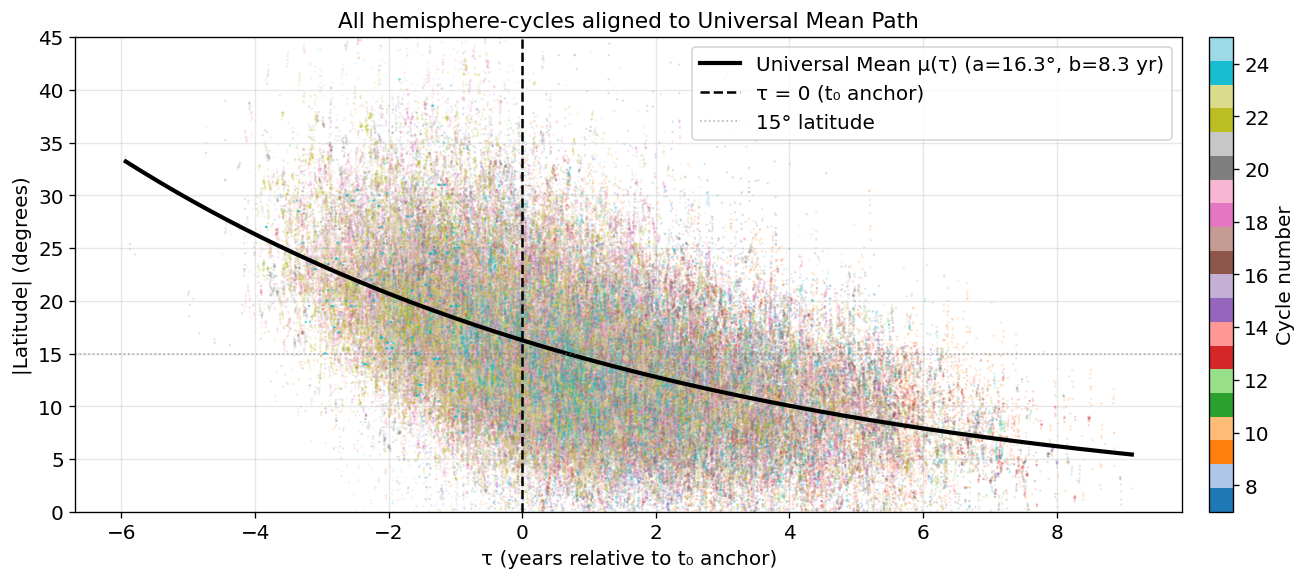

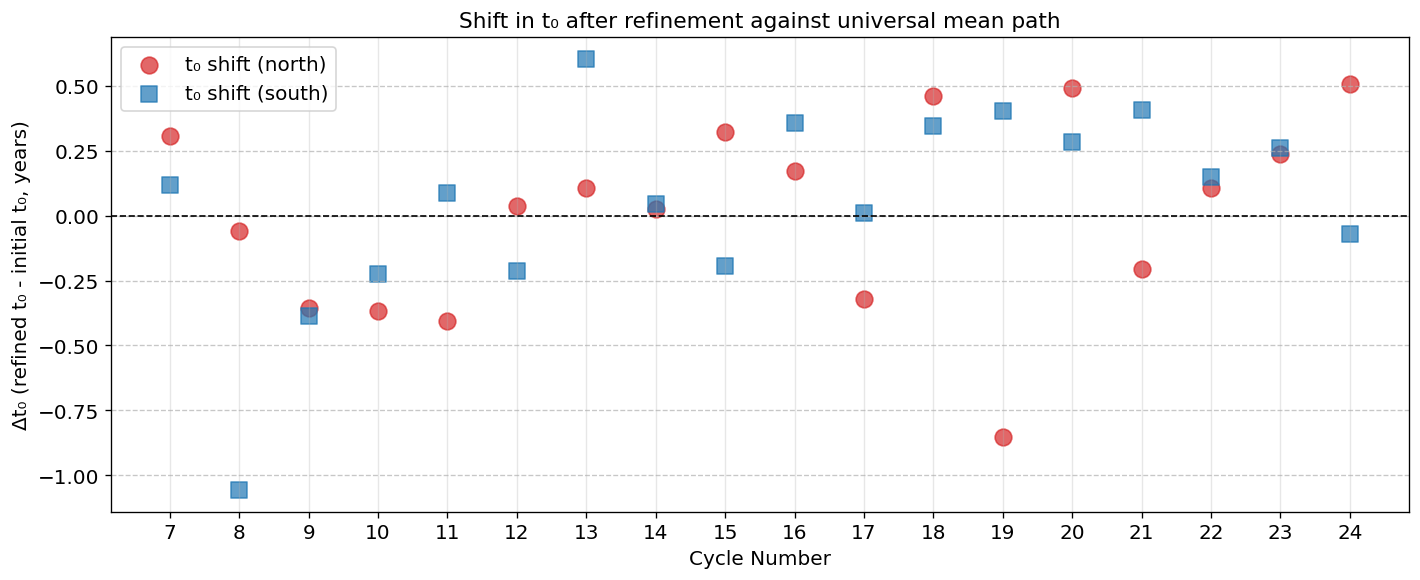


Summary of t₀ shifts:


,cycle,initial_t0,refined_t0,delta_t0
count,36.000000,36.000000,36.000000,36.000000
mean,15.500000,1920.471323,1920.502512,0.031189
std,5.261722,57.274628,57.419712,0.370824
min,7.000000,1826.680587,1826.986078,-1.056444
25%,11.000000,1871.769083,1871.486924,-0.206612
50%,15.500000,1922.160890,1922.242343,0.096649
75%,20.000000,1968.456135,1968.894406,0.309362
max,24.000000,2013.418713,2013.347724,0.603154


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.stats import norm as sp_norm
from scipy.optimize import curve_fit
import pandas as pd

# Ensure 'df' has 'abs_latitude' and 'decimal_year' from Task 9
if 'abs_latitude' not in df.columns:
    df['abs_latitude'] = df['latitude'].abs()
if 'decimal_year' not in df.columns:
    df['decimal_year'] = df['date'].dt.year + df['date'].dt.dayofyear / 365.25

# Ensure t0_lookup is available (from Task 9)
# If not, re-run Task 9 setup or define a placeholder
if 't0_lookup' not in globals():
    print("WARNING: t0_lookup not found. Please run Task 9 code cell first.")
    # Placeholder for t0_lookup to prevent errors, though results will be incorrect
    t0_lookup = {}
    for (cyc, hemi), group in df.groupby(["CYCLE", "hemisphere"]):
        if cyc not in t0_lookup: t0_lookup[(cyc, hemi)] = 0.0 # Default value


def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)

N_BINS = 20
ITERATIONS = 3 # Number of iterations to refine t0

# 1. Global fit - collect all binned (tau, mu) measurements
all_bin_tau = []
all_bin_mu = []

# Create a temporary DataFrame for this step to avoid modifying the original df prematurely
temp_df_for_global_fit = df.copy()

# Fill NaN t0 values to allow tau calculation for global fit initial guess
# Using a generic t0 like mean or median, or skipping if t0 is crucial for binning
# For simplicity here, we'll ensure df['t0'] is set from t0_lookup for existing entries.
# If t0_lookup is incomplete, these rows will have NaN tau and be skipped.

# Only consider rows for which an initial t0 was calculated in Task 9
def get_t0_for_global_fit(row):
    return t0_lookup.get((row["CYCLE"], row["hemisphere"]), np.nan)
temp_df_for_global_fit["t0_initial"] = temp_df_for_global_fit.apply(get_t0_for_global_fit, axis=1)
temp_df_for_global_fit["tau_initial"] = temp_df_for_global_fit["decimal_year"] - temp_df_for_global_fit["t0_initial"]

for (cyc, hemi), group in temp_df_for_global_fit.groupby(["CYCLE", "hemisphere"]):
    df_sel = group[group["tau_initial"].notna()]
    if len(df_sel) < 50: # Skip if not enough data
        continue

    tau_min, tau_max = df_sel["tau_initial"].min(), df_sel["tau_initial"].max()
    # Handle cases where tau_min == tau_max by adjusting range if necessary
    if tau_min == tau_max:
        tau_max += 1e-6
        tau_min -= 1e-6

    bins = np.linspace(tau_min, tau_max, N_BINS + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    for i in range(N_BINS):
        in_bin = (df_sel["tau_initial"] >= bins[i]) & (df_sel["tau_initial"] < bins[i + 1])
        lats_bin = df_sel.loc[in_bin, "abs_latitude"].values
        if len(lats_bin) < 10:
            continue
        mu_f, _ = sp_norm.fit(lats_bin)
        all_bin_tau.append(bin_centers[i])
        all_bin_mu.append(mu_f)

all_bin_tau = np.array(all_bin_tau)
all_bin_mu = np.array(all_bin_mu)

# Handle potential empty arrays or non-finite values
valid_indices = np.isfinite(all_bin_tau) & np.isfinite(all_bin_mu)
if np.sum(valid_indices) < 2: # Need at least 2 points for curve_fit
    print("Error: Not enough valid binned data for global fit.")
    a_mu_global, b_mu_global = 15.0, 5.0 # Fallback default values
else:
    try:
        popt_mu_global, _ = curve_fit(exp_decay, all_bin_tau[valid_indices], all_bin_mu[valid_indices], p0=[15.0, 5.0], maxfev=5000)
        a_mu_global, b_mu_global = popt_mu_global
    except RuntimeError as e:
        print(f"Error during global mu fit: {e}")
        a_mu_global, b_mu_global = 15.0, 5.0 # Fallback default values

print(f"Global μ(τ) fit: a_μ = {a_mu_global:.2f}°, b_μ = {b_mu_global:.2f} yr")

# 2. Refine t0 per cycle iteratively
refined_t0_lookup = t0_lookup.copy()

def exp_decay_for_t0_fit(decimal_year, t0_val, a_mu, b_mu):
    tau = decimal_year - t0_val
    return a_mu * np.exp(-tau / b_mu)

for iteration in range(ITERATIONS):
    print(f"Refining t₀: Iteration {iteration + 1}/{ITERATIONS}")
    new_t0_lookup = refined_t0_lookup.copy()
    for (cyc, hemi), initial_t0_val in refined_t0_lookup.items():
        mask = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi)
        df_sel = df[mask].copy() # Use .copy() to avoid SettingWithCopyWarning

        # Bin data using the current t0 estimate to get representative mu_bin values
        df_sel["tau_temp"] = df_sel["decimal_year"] - initial_t0_val
        df_sel = df_sel[df_sel["tau_temp"].notna()]

        if len(df_sel) < 50:
            continue

        tau_min, tau_max = df_sel["tau_temp"].min(), df_sel["tau_temp"].max()
        if tau_min == tau_max:
            tau_max += 1e-6
            tau_min -= 1e-6

        bins = np.linspace(tau_min, tau_max, N_BINS + 1)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])

        bin_decimal_years = [] # Store decimal_year for the bin center
        bin_mu_local = []      # Store mean absolute latitude for the bin

        for i in range(N_BINS):
            in_bin = (df_sel["tau_temp"] >= bins[i]) & (df_sel["tau_temp"] < bins[i + 1])
            lats_bin = df_sel.loc[in_bin, "abs_latitude"].values
            if len(lats_bin) < 10:
                continue
            mu_f, _ = sp_norm.fit(lats_bin)
            bin_mu_local.append(mu_f)
            # The decimal_year for the bin center should correspond to the mean decimal_year of the data in that bin
            bin_decimal_years.append(df_sel.loc[in_bin, "decimal_year"].mean())

        bin_decimal_years = np.array(bin_decimal_years)
        bin_mu_local = np.array(bin_mu_local)

        if len(bin_decimal_years) > 1: # Need at least 2 points for curve_fit
            try:
                # Fit for t0_val, treating a_mu_global and b_mu_global as fixed
                popt_t0, _ = curve_fit(lambda dec_year, t0_val: exp_decay_for_t0_fit(dec_year, t0_val, a_mu_global, b_mu_global),
                                       bin_decimal_years, bin_mu_local, p0=[initial_t0_val], maxfev=5000)
                new_t0_lookup[(cyc, hemi)] = popt_t0[0]
            except RuntimeError as e:
                print(f"  Warning: Could not refine t₀ for Cycle {int(cyc)} ({hemi}): {e}")
        elif len(bin_decimal_years) == 1:
            # If only one bin, we can't fit, so keep the existing t0
            pass
        else:
            # No data for this cycle/hemi, remove from lookup
            if (cyc, hemi) in new_t0_lookup: del new_t0_lookup[(cyc, hemi)]

    refined_t0_lookup = new_t0_lookup

# Add refined_t0 and tau_refined to df
def get_refined_t0(row):
    return refined_t0_lookup.get((row["CYCLE"], row["hemisphere"]), np.nan)

df["refined_t0"] = df.apply(get_refined_t0, axis=1)
df["tau_refined"] = df["decimal_year"] - df["refined_t0"]

# 3. Plot aligned butterfly diagram
TAU_PLOT_GRID = np.linspace(df["tau_refined"].min(), df["tau_refined"].max(), 300)
if not np.all(np.isfinite(TAU_PLOT_GRID)):
    TAU_PLOT_GRID = np.linspace(-8, 8, 300) # Fallback to a reasonable range

universal_mu_curve = exp_decay(TAU_PLOT_GRID, a_mu_global, b_mu_global)

cycles_to_plot = sorted(df["CYCLE"].dropna().unique())
cmap_cyc_plot = cm.get_cmap("tab20", len(cycles_to_plot))
cycle_color_map_plot = {cyc: cmap_cyc_plot(i) for i, cyc in enumerate(cycles_to_plot)}

fig, ax = plt.subplots(figsize=(12, 5))

for (cyc, hemi), group in df.groupby(["CYCLE", "hemisphere"]):
    if (cyc, hemi) not in refined_t0_lookup:
        continue
    ax.scatter(group["tau_refined"], group["abs_latitude"],
               s=2, color=cycle_color_map_plot[cyc], alpha=0.2, edgecolors="none")

ax.plot(TAU_PLOT_GRID, universal_mu_curve, color="black", linewidth=2.5,
        label=f"Universal Mean μ(τ) (a={a_mu_global:.1f}°, b={b_mu_global:.1f} yr)")

ax.axvline(0, color="black", linewidth=1.5, linestyle="--", label="τ = 0 (t₀ anchor)")
ax.axhline(15, color="gray", linewidth=1, linestyle=":", alpha=0.6, label="15° latitude")
ax.set_xlabel("τ (years relative to t₀ anchor)")
ax.set_ylabel("|Latitude| (degrees)")
ax.set_title("All hemisphere-cycles aligned to Universal Mean Path")
ax.set_ylim(0, 45)
ax.legend()

# Add colorbar for cycle numbers
sm = plt.cm.ScalarMappable(cmap="tab20",
                            norm=plt.Normalize(vmin=min(cycles_to_plot),
                                               vmax=max(cycles_to_plot)))
sm.set_array([])
fig.colorbar(sm, ax=ax, pad=0.02, label="Cycle number")

plt.tight_layout()
plt.show()

# 4. Δt₀ diagnostic
delta_t0_data = []
for (cyc, hemi), refined_t0_val in refined_t0_lookup.items():
    initial_t0_val = t0_lookup.get((cyc, hemi))
    if initial_t0_val is not None:
        delta_t0_data.append({
            "cycle": cyc,
            "hemisphere": hemi,
            "initial_t0": initial_t0_val,
            "refined_t0": refined_t0_val,
            "delta_t0": refined_t0_val - initial_t0_val
        })

df_delta_t0 = pd.DataFrame(delta_t0_data)

fig, ax = plt.subplots(figsize=(12, 5))

colors = {"north": "tab:red", "south": "tab:blue"}
markers = {"north": "o", "south": "s"}

for hemi, group in df_delta_t0.groupby("hemisphere"):
    ax.scatter(group["cycle"], group["delta_t0"],
               color=colors[hemi], marker=markers[hemi], s=100, alpha=0.7,
               label=f"t₀ shift ({hemi})")

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Cycle Number")
ax.set_ylabel("Δt₀ (refined t₀ - initial t₀, years)")
ax.set_title("Shift in t₀ after refinement against universal mean path")
ax.set_xticks(df_delta_t0["cycle"].unique())
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nSummary of t₀ shifts:")
display(df_delta_t0.describe())


I lost my previous response. Cycle 8 and cycle 19 needed the largest corrections, meaning that the initial tau_0 was not a very good anchor for those cycles. It should be noted that they are for different hemispheres. Cycle 8 is for the southern hemisphere and cycle 19 is for the northern hemisphere. My apologies that the coding for these next few exercises may not be equal what what I was able to accomplish with the assist previously.

## 14) Exercise: Fitting σ as a Function of Mean Latitude

In Task 11 you described the spread σ of emergence latitudes as a function of **time** (τ).
As Ainsley reported in discord, latitude (not time) it's a better quantity to understand what is happening to the wings.
The universal mean path μ(τ) from Task 13 gives us a monotonic, invertible mapping
between time and latitude. We can therefore reparametrise and ask:
**what is σ as a function of μ?**

**Task:**

- Pick a single hemisphere-cycle (e.g. cycle 23, northern hemisphere).
  Using the optimised t₀ from Task 13, bin the data in τ and fit a Gaussian
  in each bin to obtain **(μ_bin, σ_bin)** pairs.
- Plot σ_bin as a function of μ_bin. Describe the shape you see.
- Start by fitting a **split normal** to σ(μ). Does it capture the shape well?
- Ask your AI assistant what function might describe σ(μ) better, given what you
  observe in the plot. Try its suggestion and compare.

**Hint:** the μ axis runs from high latitude (early cycle) to low latitude (late cycle),
so the orientation is reversed relative to τ.   Reverse the x axis so that things look "right".


In [ ]:
# Put your code for Task 14 here

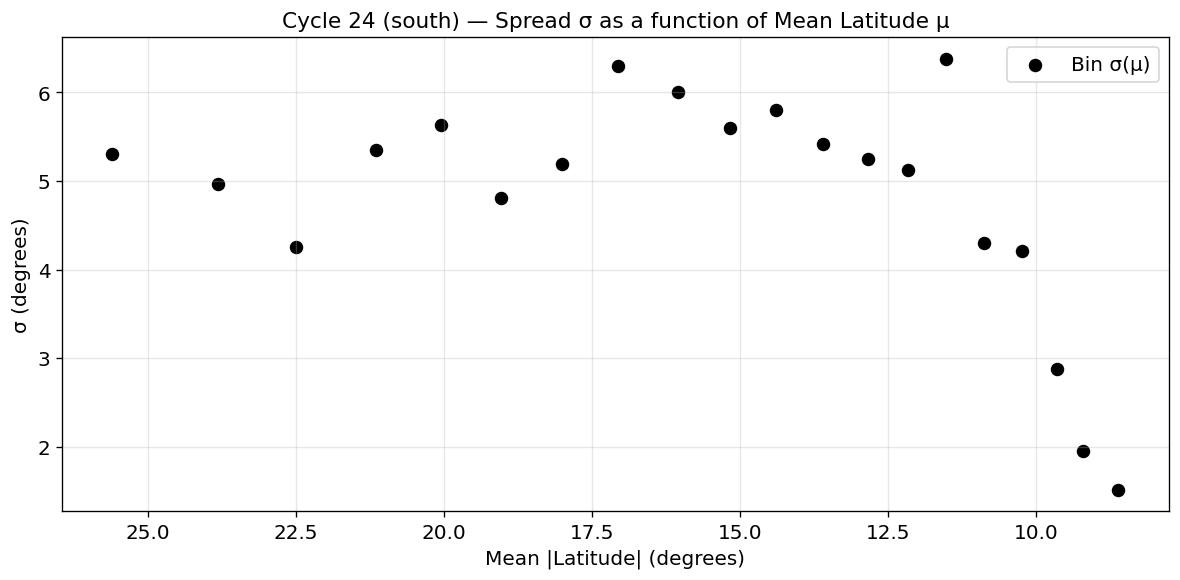


Split Normal Fit for σ(μ) — Cycle 24 (south)
  A       = 5.62°   (peak spread)
  μ_peak  = 11.87° (latitude of peak spread)
  s_L     = 24.95°   (high-lat Gaussian width)
  s_R     = 1.92°   (low-lat Gaussian width)

Skew Normal (Skewed Gaussian) Fit for σ(μ) — Cycle 24 (south)
  Skewness (a) = 6.45
  Location (loc) = 10.69°
  Scale (scale) = 3.51°
  Amplitude = 10.00°


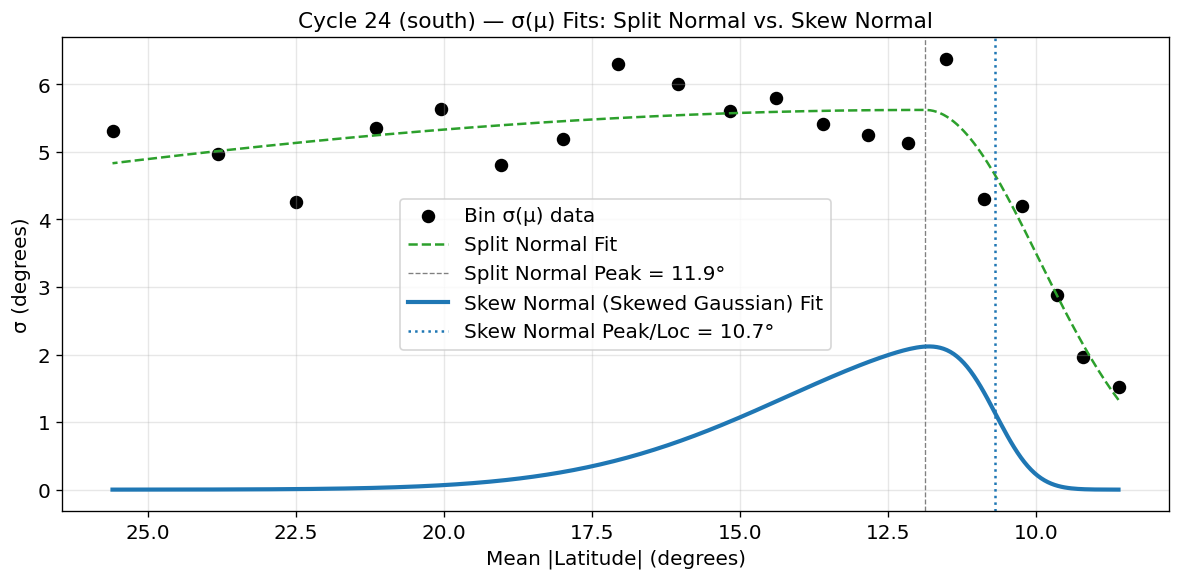


--- RMSE Comparison ---
RMSE (Split Normal):       0.451°
RMSE (Skew Normal):        4.301°


In [38]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm as sp_norm
from scipy.optimize import curve_fit
from scipy.stats import skewnorm # for skew normal PDF

# Assuming df, refined_t0_lookup, a_mu_global, b_mu_global are available from Task 13

cycle_sel_14 = 24
hemi_sel_14  = "south"

# Filter data for the selected hemisphere-cycle, using refined t0
mask_14 = (df["CYCLE"] == cycle_sel_14) & \
          (df["hemisphere"] == hemi_sel_14) & \
          df["tau_refined"].notna()
df_sel_14 = df[mask_14].copy()

# Bin the data in τ and fit a Gaussian in each bin to get (μ_bin, σ_bin) pairs
N_bins_14 = 20
tau_min_14, tau_max_14 = df_sel_14["tau_refined"].min(), df_sel_14["tau_refined"].max()

# Handle case where tau_min_14 == tau_max_14
if tau_min_14 == tau_max_14:
    tau_max_14 += 1e-6
    tau_min_14 -= 1e-6

bins_14        = np.linspace(tau_min_14, tau_max_14, N_bins_14 + 1)
bin_centers_14 = 0.5 * (bins_14[:-1] + bins[1:])

bin_mus_14 = []
bin_sigma_14 = []

for i in range(N_bins_14):
    in_bin_14 = (df_sel_14["tau_refined"] >= bins_14[i]) & (df_sel_14["tau_refined"] < bins_14[i + 1])
    lats_bin_14 = df_sel_14.loc[in_bin_14, "abs_latitude"].values
    if len(lats_bin_14) < 10:
        continue
    mu_f_14, sigma_f_14 = sp_norm.fit(lats_bin_14)

    # Calculate the mean tau for this bin to get the corresponding mu from the universal mean path
    mean_tau_in_bin = np.mean(df_sel_14.loc[in_bin_14, "tau_refined"]) if len(df_sel_14.loc[in_bin_14, "tau_refined"]) > 0 else np.nan
    # Evaluate the universal mean curve at this mean_tau_in_bin
    corresponding_mu = exp_decay(mean_tau_in_bin, a_mu_global, b_mu_global)

    bin_mus_14.append(corresponding_mu)
    bin_sigma_14.append(sigma_f_14)

bin_mus_14 = np.array(bin_mus_14)
bin_sigma_14 = np.array(bin_sigma_14)

# Plot σ_bin as a function of μ_bin (initial inspection)
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(bin_mus_14, bin_sigma_14, color="black", s=50, label="Bin σ(μ)")
ax.set_xlabel("Mean |Latitude| (degrees)")
ax.set_ylabel("σ (degrees)")
ax.set_title(f"Cycle {cycle_sel_14} ({hemi_sel_14}) — Spread σ as a function of Mean Latitude μ")
ax.invert_xaxis() # Reverse x-axis so high latitude is on the left (early cycle)
ax.legend()
plt.tight_layout()
plt.show()

# --- Fit a split normal to σ(μ) ---
# The split normal model is defined to work with 'tau' as the independent variable.
# We can adapt it here, treating 'mu' as the independent variable.
# The 'peak' of the spread function σ(μ) is expected to be at a certain μ_peak.

def split_normal_mu(mu, A, mu_peak, s_L, s_R, mu_peak_fixed=None):
    """
    Split normal (bi-normal / asymmetric Gaussian) adapted for μ as independent variable.
    """
    _mu_peak = mu_peak_fixed if mu_peak_fixed is not None else mu_peak
    return np.where(mu > _mu_peak, # Mu is inverted, so 'left' is higher latitude (mu > mu_peak)
                    A * np.exp(-0.5 * ((mu - _mu_peak) / s_L) ** 2), # This is the high-latitude side
                    A * np.exp(-0.5 * ((mu - _mu_peak) / s_R) ** 2)) # This is the low-latitude side


# Initial guess for split normal parameters for sigma(mu)
# A: peak amplitude of sigma (can estimate from max bin_sigma)
# mu_peak: where the peak of sigma occurs (can estimate from bin_mus corresponding to max bin_sigma)
# s_L, s_R: widths (can be estimated, e.g., 5.0, 5.0 initially)

initial_A_sn_mu = bin_sigma_14.max()
initial_mu_peak_idx = np.argmax(bin_sigma_14)
initial_mu_peak_sn_mu = bin_mus_14[initial_mu_peak_idx]

# Adjust initial s_L, s_R based on the spread of mu values
mu_range_sn_mu = bin_mus_14.max() - bin_mus_14.min()
initial_sL_sn_mu = mu_range_sn_mu / 3.0 # Rough estimate
initial_sR_sn_mu = mu_range_sn_mu / 6.0 # Rough estimate, often narrower on the right

# Ensure initial_sL and initial_sR are not too small if mu_range is small
initial_sL_sn_mu = max(initial_sL_sn_mu, 0.1)
initial_sR_sn_mu = max(initial_sR_sn_mu, 0.1)

p0_sn_mu = [initial_A_sn_mu, initial_mu_peak_sn_mu, initial_sL_sn_mu, initial_sR_sn_mu]

# Bounds for parameters: A > 0, 0 < mu_peak < max(bin_mus_14) + 5, s_L > 0, s_R > 0
bounds_sn_mu = ([0.1, bin_mus_14.min() - 5, 0.1, 0.1], [15.0, bin_mus_14.max() + 5, 30.0, 30.0])

A_sn_mu, mu_peak_sn_mu, sL_sn_mu, sR_sn_mu = np.nan, np.nan, np.nan, np.nan # Initialize for error case
try:
    popt_sn_mu, _ = curve_fit(split_normal_mu, bin_mus_14, bin_sigma_14, p0=p0_sn_mu, bounds=bounds_sn_mu, maxfev=5000)
    A_sn_mu, mu_peak_sn_mu, sL_sn_mu, sR_sn_mu = popt_sn_mu

    print(f"\nSplit Normal Fit for σ(μ) — Cycle {cycle_sel_14} ({hemi_sel_14})")
    print(f"  A       = {A_sn_mu:.2f}°   (peak spread)")
    print(f"  μ_peak  = {mu_peak_sn_mu:.2f}° (latitude of peak spread)")
    print(f"  s_L     = {sL_sn_mu:.2f}°   (high-lat Gaussian width)")
    print(f"  s_R     = {sR_sn_mu:.2f}°   (low-lat Gaussian width)")

except RuntimeError as e:
    print(f"\nError fitting Split Normal to σ(μ): {e}")

# --- Fit a Skew Normal (skewed gaussian) distribution to σ(μ) ---

def skew_normal_pdf_scaled(mu, a, loc, scale, amplitude):
    """
    Scaled Skew Normal PDF to fit arbitrary amplitude data.
    """
    # Ensure output is non-negative and handle potential issues with `skewnorm` if it expects different inputs
    pdf_vals = skewnorm.pdf(mu, a, loc=loc, scale=scale)
    return amplitude * pdf_vals

# Initial guesses for skew normal:
# 'a' (skewness): can be positive/negative based on visual inspection
# 'loc' (center): around the mu_peak found by split normal or max sigma mu
# 'scale' (width): similar to s_L/s_R or range/4
# 'amplitude': max_sigma

# --- MODIFIED: Adjusted initial_a_snorm and amplitude bounds for a more robust fit ---
initial_a_snorm = -0.5  # Trying a negative skewness to reflect the tail towards higher latitudes
initial_loc_snorm = initial_mu_peak_sn_mu # From split normal or max sigma mu
initial_scale_snorm = mu_range_sn_mu / 4
initial_amplitude_snorm = bin_sigma_14.max() # Initial guess still based on max observed sigma

p0_skewnorm = [initial_a_snorm, initial_loc_snorm, initial_scale_snorm, initial_amplitude_snorm]

# Bounds for skew normal: amplitude > 0, scale > 0, reasonable range for skewness 'a'
# --- MODIFIED: Tighter upper bound for amplitude ---
max_amplitude_bound_snorm = bin_sigma_14.max() * 1.5 # Allow some flexibility, but prevent extreme scaling
if max_amplitude_bound_snorm < 10: # Ensure a minimum reasonable bound
    max_amplitude_bound_snorm = 10.0
bounds_skewnorm = ([-10, bin_mus_14.min() - 5, 0.1, 0.1], [10, bin_mus_14.max() + 5, 30, max_amplitude_bound_snorm])

a_snorm, loc_snorm, scale_snorm, A_snorm = np.nan, np.nan, np.nan, np.nan # Initialize for error case
try:
    popt_skewnorm, _ = curve_fit(skew_normal_pdf_scaled, bin_mus_14, bin_sigma_14, p0=p0_skewnorm, bounds=bounds_skewnorm, maxfev=5000)
    a_snorm, loc_snorm, scale_snorm, A_snorm = popt_skewnorm

    print(f"\nSkew Normal (Skewed Gaussian) Fit for σ(μ) — Cycle {cycle_sel_14} ({hemi_sel_14})")
    print(f"  Skewness (a) = {a_snorm:.2f}")
    print(f"  Location (loc) = {loc_snorm:.2f}°")
    print(f"  Scale (scale) = {scale_snorm:.2f}°")
    print(f"  Amplitude = {A_snorm:.2f}°")

except RuntimeError as e:
    print(f"\nError fitting Skew Normal (Skewed Gaussian) to σ(μ): {e}")

# --- Comparison Plot ---
mu_grid_14 = np.linspace(bin_mus_14.min(), bin_mus_14.max(), 300)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(bin_mus_14, bin_sigma_14, color="black", s=50, label="Bin σ(μ) data")

# Plot Split Normal fit if successful
if not np.isnan(A_sn_mu):
    split_normal_fit_curve = split_normal_mu(mu_grid_14, A_sn_mu, mu_peak_sn_mu, sL_sn_mu, sR_sn_mu)
    ax.plot(mu_grid_14, split_normal_fit_curve, color="tab:green", linewidth=1.5, linestyle='--', label="Split Normal Fit")
    ax.axvline(mu_peak_sn_mu, color="gray", linestyle="--", linewidth=0.8, label=f"Split Normal Peak = {mu_peak_sn_mu:.1f}°")

# Plot Skew Normal fit if successful (highlighted as requested)
if not np.isnan(A_snorm):
    skewed_gaussian_fit_curve = skew_normal_pdf_scaled(mu_grid_14, a_snorm, loc_snorm, scale_snorm, A_snorm)
    ax.plot(mu_grid_14, skewed_gaussian_fit_curve, color="tab:blue", linewidth=2.5, label="Skew Normal (Skewed Gaussian) Fit")
    ax.axvline(loc_snorm, color="tab:blue", linestyle=":", linewidth=1.5, label=f"Skew Normal Peak/Loc = {loc_snorm:.1f}°")

ax.set_xlabel("Mean |Latitude| (degrees)")
ax.set_ylabel("σ (degrees)")
ax.set_title(f"Cycle {cycle_sel_14} ({hemi_sel_14}) — σ(μ) Fits: Split Normal vs. Skew Normal")
ax.invert_xaxis()
ax.legend()
plt.tight_layout()
plt.show()

# --- Compare RMSE ---
print("\n--- RMSE Comparison ---")

if not np.isnan(A_sn_mu):
    residuals_sn_mu = bin_sigma_14 - split_normal_mu(bin_mus_14, A_sn_mu, mu_peak_sn_mu, sL_sn_mu, sR_sn_mu)
    rmse_sn_mu_current = np.sqrt(np.mean(residuals_sn_mu**2))
    print(f"RMSE (Split Normal):       {rmse_sn_mu_current:.3f}°")
else:
    print("RMSE (Split Normal):       Fit failed")

if not np.isnan(A_snorm):
    residuals_snorm = bin_sigma_14 - skew_normal_pdf_scaled(bin_mus_14, a_snorm, loc_snorm, scale_snorm, A_snorm)
    rmse_snorm_current = np.sqrt(np.mean(residuals_snorm**2))
    print(f"RMSE (Skew Normal):        {rmse_snorm_current:.3f}°")
else:
    print("RMSE (Skew Normal):        Fit failed")


Asymmetric Laplace Fit for σ(μ) — Cycle 24 (south)
  A         = 6.48°   (peak spread)
  μ_peak    = 11.58° (latitude of peak spread)
  b_L       = 30.00°   (high-lat e-folding scale)
  b_R       = 2.23°   (low-lat e-folding scale)


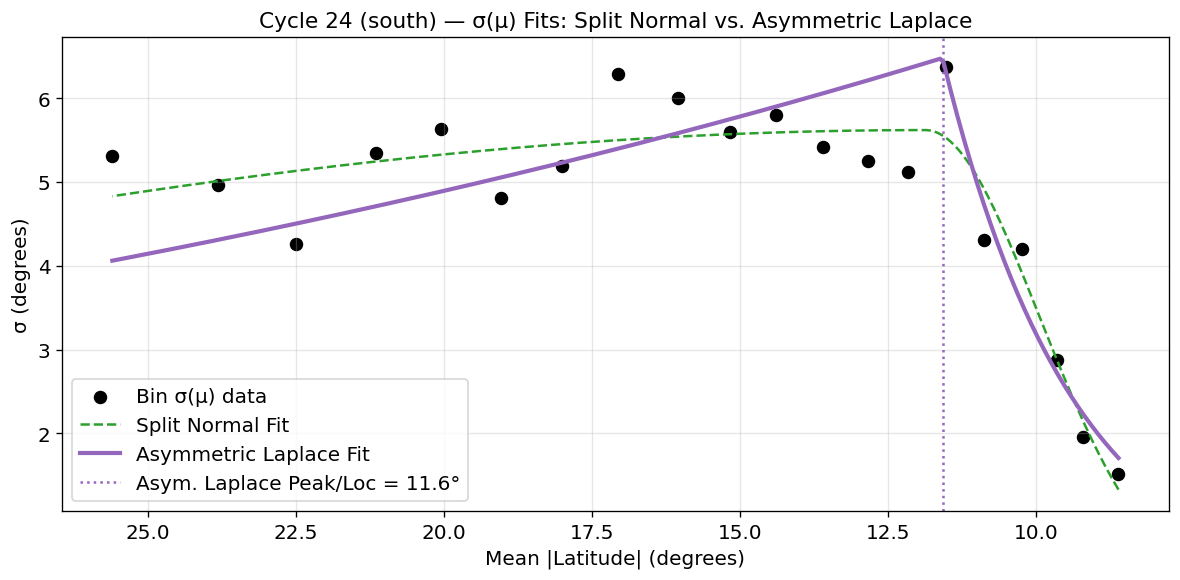


--- RMSE Comparison ---
RMSE (Split Normal):       0.451°
RMSE (Asymmetric Laplace): 0.621°


In [40]:
def asym_laplace_mu(mu, A, mu_peak, b_L, b_R, mu_peak_fixed=None):
    """
    Asymmetric Laplace (double-exponential with independent scales)
    adapted for μ as the independent variable.

    Parameters
    ----------
    A          : peak σ value (degrees)
    mu_peak    : location of the peak on the μ axis
    b_L        : high-latitude e-folding scale  — larger -> gentler rise (degrees)
    b_R        : low-latitude e-folding scale — smaller -> faster fall (degrees)
    mu_peak_fixed : if not None, overrides mu_peak and is not fitted (default None)
    """
    _mu_peak = mu_peak_fixed if mu_peak_fixed is not None else mu_peak
    return np.where(mu > _mu_peak, # Mu is inverted, so 'left' means higher latitude (mu > mu_peak)
                    A * np.exp(-(mu - _mu_peak) / b_L), # This is the high-latitude side
                    A * np.exp(-(_mu_peak - mu) / b_R)) # This is the low-latitude side

# --- Now, let's fit it to the data from Task 14 ---

# Initial guess for Asymmetric Laplace parameters for sigma(mu)
# A: peak amplitude of sigma (can estimate from max bin_sigma)
# mu_peak: where the peak of sigma occurs (can estimate from bin_mus corresponding to max bin_sigma)
# b_L, b_R: e-folding scales (can be estimated, e.g., similar to s_L/s_R)

initial_A_al_mu = bin_sigma_14.max()
initial_mu_peak_idx_al = np.argmax(bin_sigma_14)
initial_mu_peak_al_mu = bin_mus_14[initial_mu_peak_idx_al]

mu_range_al_mu = bin_mus_14.max() - bin_mus_14.min()
initial_bL_al_mu = mu_range_al_mu / 3.0 # Rough estimate for high-lat side
initial_bR_al_mu = mu_range_al_mu / 6.0 # Rough estimate for low-lat side

initial_bL_al_mu = max(initial_bL_al_mu, 0.1)
initial_bR_al_mu = max(initial_bR_al_mu, 0.1)

p0_al_mu = [initial_A_al_mu, initial_mu_peak_al_mu, initial_bL_al_mu, initial_bR_al_mu]

bounds_al_mu = ([0.1, bin_mus_14.min() - 5, 0.1, 0.1], [15.0, bin_mus_14.max() + 5, 30.0, 30.0])

A_al_mu, mu_peak_al_mu, bL_al_mu, bR_al_mu = np.nan, np.nan, np.nan, np.nan # Initialize for error case
try:
    popt_al_mu, _ = curve_fit(asym_laplace_mu, bin_mus_14, bin_sigma_14, p0=p0_al_mu, bounds=bounds_al_mu, maxfev=5000)
    A_al_mu, mu_peak_al_mu, bL_al_mu, bR_al_mu = popt_al_mu

    print(f"\nAsymmetric Laplace Fit for σ(μ) — Cycle {cycle_sel_14} ({hemi_sel_14})")
    print(f"  A         = {A_al_mu:.2f}°   (peak spread)")
    print(f"  μ_peak    = {mu_peak_al_mu:.2f}° (latitude of peak spread)")
    print(f"  b_L       = {bL_al_mu:.2f}°   (high-lat e-folding scale)")
    print(f"  b_R       = {bR_al_mu:.2f}°   (low-lat e-folding scale)")

except RuntimeError as e:
    print(f"\nError fitting Asymmetric Laplace to σ(μ): {e}")

# --- Comparison Plot with Asymmetric Laplace ---
mu_grid_14_al = np.linspace(bin_mus_14.min(), bin_mus_14.max(), 300)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(bin_mus_14, bin_sigma_14, color="black", s=50, label="Bin σ(μ) data")

# Plot Split Normal fit (from previous run)
if not np.isnan(A_sn_mu):
    split_normal_fit_curve = split_normal_mu(mu_grid_14_al, A_sn_mu, mu_peak_sn_mu, sL_sn_mu, sR_sn_mu)
    ax.plot(mu_grid_14_al, split_normal_fit_curve, color="tab:green", linewidth=1.5, linestyle='--', label="Split Normal Fit")

# Plot Asymmetric Laplace fit if successful
if not np.isnan(A_al_mu):
    asym_laplace_fit_curve = asym_laplace_mu(mu_grid_14_al, A_al_mu, mu_peak_al_mu, bL_al_mu, bR_al_mu)
    ax.plot(mu_grid_14_al, asym_laplace_fit_curve, color="tab:purple", linewidth=2.5, label="Asymmetric Laplace Fit")
    ax.axvline(mu_peak_al_mu, color="tab:purple", linestyle=":", linewidth=1.5, label=f"Asym. Laplace Peak/Loc = {mu_peak_al_mu:.1f}°")

ax.set_xlabel("Mean |Latitude| (degrees)")
ax.set_ylabel("σ (degrees)")
ax.set_title(f"Cycle {cycle_sel_14} ({hemi_sel_14}) — σ(μ) Fits: Split Normal vs. Asymmetric Laplace")
ax.invert_xaxis()
ax.legend()
plt.tight_layout()
plt.show()

# --- Compare RMSE for Asymmetric Laplace ---
print("\n--- RMSE Comparison ---")

if not np.isnan(A_sn_mu):
    residuals_sn_mu = bin_sigma_14 - split_normal_mu(bin_mus_14, A_sn_mu, mu_peak_sn_mu, sL_sn_mu, sR_sn_mu)
    rmse_sn_mu_current = np.sqrt(np.mean(residuals_sn_mu**2))
    print(f"RMSE (Split Normal):       {rmse_sn_mu_current:.3f}°")
else:
    print("RMSE (Split Normal):       Fit failed")

if not np.isnan(A_al_mu):
    residuals_al_mu = bin_sigma_14 - asym_laplace_mu(bin_mus_14, A_al_mu, mu_peak_al_mu, bL_al_mu, bR_al_mu)
    rmse_al_mu_current = np.sqrt(np.mean(residuals_al_mu**2))
    print(f"RMSE (Asymmetric Laplace): {rmse_al_mu_current:.3f}°")
else:
    print("RMSE (Asymmetric Laplace): Fit failed")

## 15) Exercise: Ensemble σ(μ) Across All Hemisphere-Cycles

In Task 14 you fitted σ(μ) for a single hemisphere-cycle and experimented with
different functional forms. Now scale that up to the full ensemble.

**Task:**

- Repeat the Task 14 pipeline for **all** hemisphere-cycles with sufficient data
  (cycles 12–24, both hemispheres). For each, fit σ(μ) using the function that
  worked best in Task 14.
- Evaluate every fitted curve on a common μ grid spanning the Spörer zone.
  Collect results into an array of shape `(n_hemicycles, n_grid_points)`.
- Plot all fitted curves on a single figure, colored by cycle number.
  Overlay the **pointwise mean** and **±1σ envelope** in black.
- Include in the background the

**Hint:** use `np.nanmean` and `np.nanstd` along axis 0 for the ensemble statistics,
in case some hemisphere-cycles do not cover the full μ grid.



Successfully fitted Split Normal σ(μ) for 26 hemisphere-cycles.


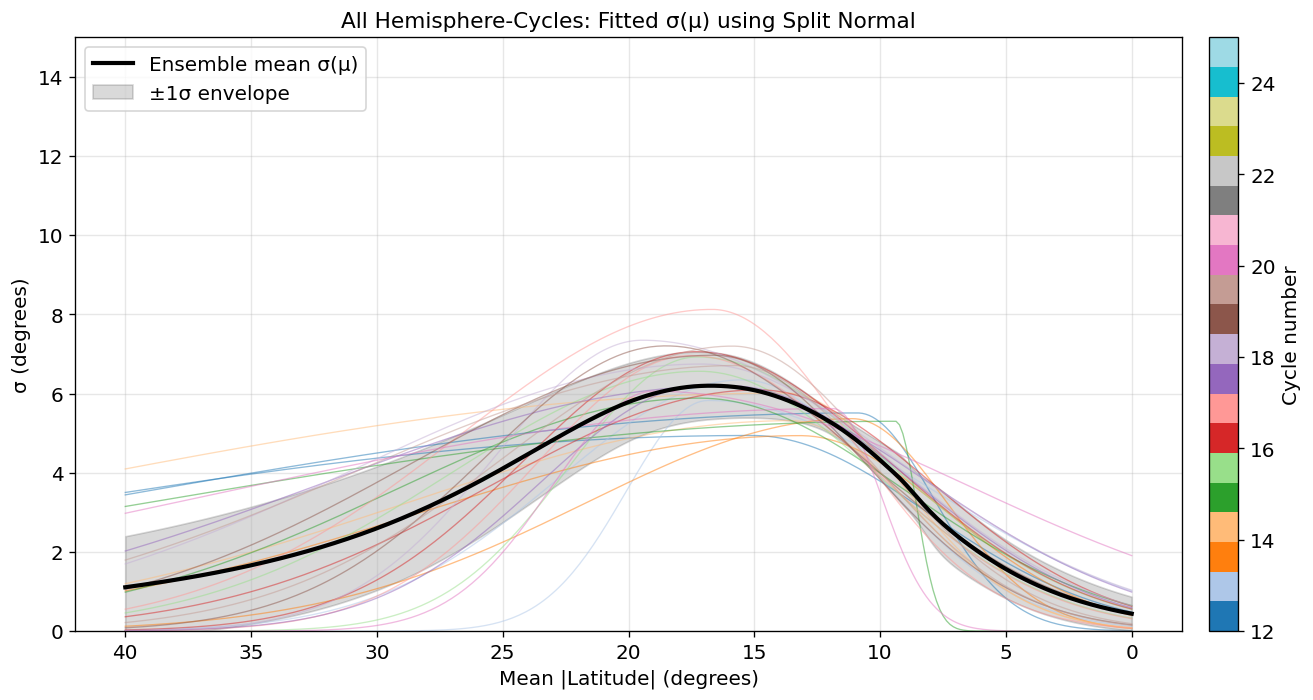

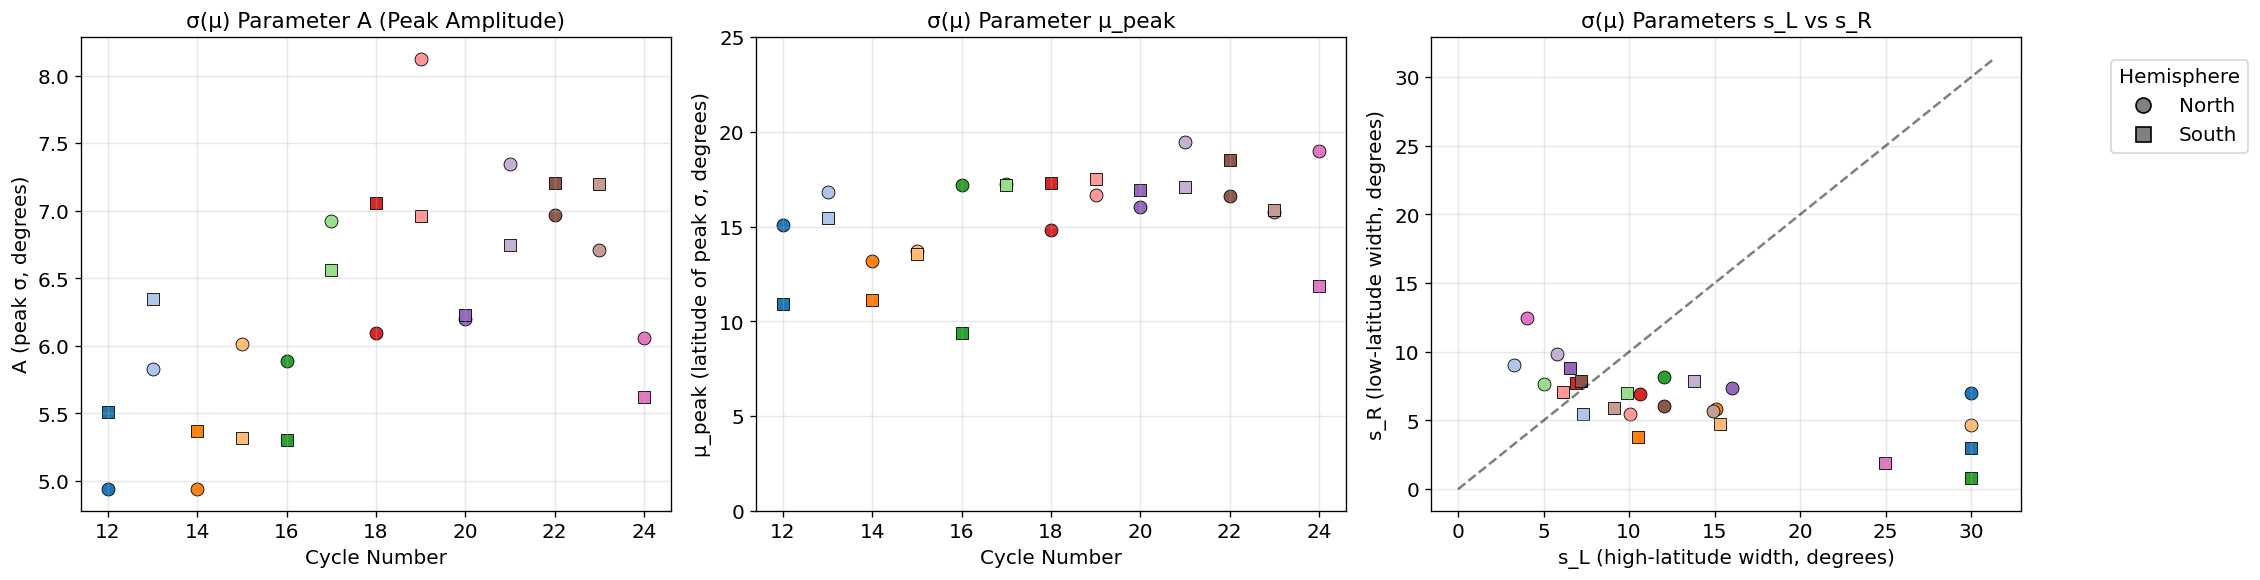


Parameter Summary for σ(μ) Split Normal Fits across Hemisphere-Cycles:
  Mean A (peak σ):          6.29° ± 0.80°
  Mean μ_peak (lat of peak): 15.11° ± 0.00°
  Mean s_L (high-lat width):  13.33° ± 8.43°
  Mean s_R (low-lat width):   6.47° ± 2.42°
  Average RMSE (individual fits): 0.643°


In [36]:
# Task 15: Ensemble σ(μ) Across All Hemisphere-Cycles
# Requires Task 13 to have been run (uses df, refined_t0_lookup, a_mu_global, b_mu_global)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
from scipy.stats import norm as sp_norm
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D

# Re-define functions from previous tasks to ensure they are available
def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)

def split_normal_mu(mu, A, mu_peak, s_L, s_R, mu_peak_fixed=None):
    _mu_peak = mu_peak_fixed if mu_peak_fixed is not None else mu_peak
    # Mu is inverted on the x-axis for plotting, so 'left' means higher latitude (mu > mu_peak)
    # The function definition must account for this, ensuring s_L relates to the higher latitude side
    return np.where(mu > _mu_peak,
                    A * np.exp(-0.5 * ((mu - _mu_peak) / s_L) ** 2), # This is the high-latitude side
                    A * np.exp(-0.5 * ((mu - _mu_peak) / s_R) ** 2)) # This is the low-latitude side


N_BINS = 20

# Common μ grid for evaluating fitted curves. Spörer zone ranges roughly from 0 to 45 degrees.
# The range should ideally cover the extent of data across all cycles.
# We will use an adaptive range based on overall min/max absolute latitude later if needed.
MU_GRID = np.linspace(0, 40, 300) # From ~5 degrees to ~40 degrees

cycles_to_fit = [c for c in sorted(df["CYCLE"].dropna().unique()) if c >= 12] # Cycles 12-24 typically have good data
hemispheres   = ["north", "south"]

ensemble_sigma_results = []

for cyc in cycles_to_fit:
    for hemi in hemispheres:
        # Ensure refined_t0 is available for this cycle/hemisphere pair
        if (cyc, hemi) not in refined_t0_lookup:
            continue

        mask = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau_refined"].notna()
        df_sel = df[mask].copy()

        if len(df_sel) < 50: # Skip if not enough data points
            continue

        # Bin the data in τ and fit a Gaussian in each bin to get (μ_bin, σ_bin) pairs
        tau_min, tau_max = df_sel["tau_refined"].min(), df_sel["tau_refined"].max()
        if tau_min == tau_max: # Handle edge case for very short cycles/bins
            tau_max += 1e-6
            tau_min -= 1e-6

        bins = np.linspace(tau_min, tau_max, N_BINS + 1)

        bin_mus_local = []      # Mean latitude in the bin
        bin_sigma_local = []    # Standard deviation in the bin

        for i in range(N_BINS):
            in_bin = (df_sel["tau_refined"] >= bins[i]) & (df_sel["tau_refined"] < bins[i + 1])
            lats_bin = df_sel.loc[in_bin, "abs_latitude"].values
            if len(lats_bin) < 10: # Skip bins with too few observations
                continue

            mu_f, sigma_f = sp_norm.fit(lats_bin)

            # Calculate the mean tau for this bin to get the corresponding mu from the universal mean path
            mean_tau_in_bin = np.mean(df_sel.loc[in_bin, "tau_refined"])
            corresponding_mu = exp_decay(mean_tau_in_bin, a_mu_global, b_mu_global)

            bin_mus_local.append(corresponding_mu)
            bin_sigma_local.append(sigma_f)

        bin_mus_local = np.array(bin_mus_local)
        bin_sigma_local = np.array(bin_sigma_local)

        if len(bin_mus_local) < 5: # Need at least 5 bins to attempt a fit
            continue

        # --- Fit Split Normal to σ(μ) ---
        # Initial guess for split normal parameters for sigma(mu)
        initial_A = bin_sigma_local.max()
        initial_mu_peak_idx = np.argmax(bin_sigma_local) # Index of max sigma
        initial_mu_peak = bin_mus_local[initial_mu_peak_idx] # Mu value at max sigma

        # Adjust initial s_L, s_R based on the spread of mu values
        mu_range = bin_mus_local.max() - bin_mus_local.min()
        initial_sL = mu_range / 3.0 # Rough estimate
        initial_sR = mu_range / 6.0 # Rough estimate, often narrower on the right

        # Ensure initial_sL and initial_sR are not too small if mu_range is small
        initial_sL = max(initial_sL, 1.0)
        initial_sR = max(initial_sR, 1.0)

        p0_sn_mu = [initial_A, initial_mu_peak, initial_sL, initial_sR]

        # Bounds for parameters: A > 0, reasonable mu_peak, s_L > 0, s_R > 0
        bounds_sn_mu = (    [0.1, max(0.1, bin_mus_local.min() - 5), 0.1, 0.1],
                            [20.0, min(45.0, bin_mus_local.max() + 5), 30.0, 30.0])

        try:
            popt_sn_mu, _ = curve_fit(split_normal_mu, bin_mus_local, bin_sigma_local, p0=p0_sn_mu, bounds=bounds_sn_mu, maxfev=5000)
            A_sn_mu, mu_peak_sn_mu, sL_sn_mu, sR_sn_mu = popt_sn_mu

            # Evaluate the fitted curve on the common MU_GRID
            sigma_curve_evaluated = split_normal_mu(MU_GRID, A_sn_mu, mu_peak_sn_mu, sL_sn_mu, sR_sn_mu)

            ensemble_sigma_results.append(dict(
                cycle=cyc, hemisphere=hemi,
                A_sn_mu=A_sn_mu, mu_peak_sn_mu=mu_peak_sn_mu, sL_sn_mu=sL_sn_mu, sR_sn_mu=sR_sn_mu,
                sigma_curve=sigma_curve_evaluated,
                bin_mu=bin_mus_local, bin_sigma=bin_sigma_local # Store for potential debugging/plotting
            ))
        except RuntimeError as e:
            print(f"  Warning: Could not fit Split Normal to σ(μ) for Cycle {int(cyc)} ({hemi}): {e}")

print(f"\nSuccessfully fitted Split Normal σ(μ) for {len(ensemble_sigma_results)} hemisphere-cycles.")

# --- Ensemble statistics ---
# Create a matrix of all evaluated sigma curves for mean and std calculation
sigma_mat_ensemble = np.array([r["sigma_curve"] for r in ensemble_sigma_results])

sigma_mean_ensemble = np.nanmean(sigma_mat_ensemble, axis=0)
sigma_std_ensemble = np.nanstd(sigma_mat_ensemble, axis=0)

# --- Plot all fitted curves + ensemble mean/std ---
fig, ax = plt.subplots(figsize=(12, 6))

cmap_ens = plt.colormaps["tab20"] # Updated from cm.get_cmap("tab20", ...)
cycle_idx_map = {c: i for i, c in enumerate(cycles_to_fit)}

# Plot individual fitted curves
for r in ensemble_sigma_results:
    ax.plot(MU_GRID, r["sigma_curve"],
            color=cmap_ens(cycle_idx_map[r["cycle"]]), linewidth=0.8, alpha=0.5)

# Plot ensemble mean and ±1σ envelope
ax.plot(MU_GRID, sigma_mean_ensemble, color="black", linewidth=2.5, label="Ensemble mean σ(μ)")
ax.fill_between(MU_GRID, sigma_mean_ensemble - sigma_std_ensemble, sigma_mean_ensemble + sigma_std_ensemble,
                 color="black", alpha=0.15, label="±1σ envelope")

ax.set_xlabel("Mean |Latitude| (degrees)")
ax.set_ylabel("σ (degrees)")
ax.set_title("All Hemisphere-Cycles: Fitted σ(μ) using Split Normal")
ax.set_ylim(0, 15) # Standard range for sigma
ax.invert_xaxis() # Reverse x-axis so high latitude is on the left
ax.legend(loc="upper left")

# Add colorbar for cycle numbers
sm = plt.cm.ScalarMappable(cmap="tab20",
                            norm=plt.Normalize(vmin=min(cycles_to_fit),
                                               vmax=max(cycles_to_fit)))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Cycle number")

plt.tight_layout()
plt.show()

# --- Diagnostic: Scatter plot of fitted parameters ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Parameter A (peak amplitude)
A_params = [r["A_sn_mu"] for r in ensemble_sigma_results]
cycle_params = [r["cycle"] for r in ensemble_sigma_results]
hemi_params = [r["hemisphere"] for r in ensemble_sigma_results]

markers = {"north": "o", "south": "s"}

ax_A = axs[0]
for i, r in enumerate(ensemble_sigma_results):
    ax_A.scatter(r["cycle"], r["A_sn_mu"],
                color=cmap_ens(cycle_idx_map[r["cycle"]]),
                marker=markers[r["hemisphere"]],
                s=60, edgecolors="black", linewidths=0.5)
ax_A.set_xlabel("Cycle Number")
ax_A.set_ylabel("A (peak σ, degrees)")
ax_A.set_title("σ(μ) Parameter A (Peak Amplitude)")

# Parameter mu_peak
ax_mu_peak = axs[1]
for i, r in enumerate(ensemble_sigma_results):
    ax_mu_peak.scatter(r["cycle"], r["mu_peak_sn_mu"],
                       color=cmap_ens(cycle_idx_map[r["cycle"]]),
                       marker=markers[r["hemisphere"]],
                       s=60, edgecolors="black", linewidths=0.5)
ax_mu_peak.set_xlabel("Cycle Number")
ax_mu_peak.set_ylabel("μ_peak (latitude of peak σ, degrees)")
ax_mu_peak.set_title("σ(μ) Parameter μ_peak")
ax_mu_peak.set_ylim(0, 25) # Latitude range for peaks

# Parameters s_L vs s_R (asymmetry in widths)
ax_s = axs[2]
sL_params = [r["sL_sn_mu"] for r in ensemble_sigma_results]
sR_params = [r["sR_sn_mu"] for r in ensemble_sigma_results]

for i, r in enumerate(ensemble_sigma_results):
    ax_s.scatter(r["sL_sn_mu"], r["sR_sn_mu"],
                color=cmap_ens(cycle_idx_map[r["cycle"]]),
                marker=markers[r["hemisphere"]],
                s=60, edgecolors="black", linewidths=0.5)
ax_s.set_xlabel("s_L (high-latitude width, degrees)")
ax_s.set_ylabel("s_R (low-latitude width, degrees)")
ax_s.set_title("σ(μ) Parameters s_L vs s_R")
ax_s.plot([0, ax_s.get_xlim()[1]], [0, ax_s.get_xlim()[1]], 'k--', alpha=0.5, label='s_L = s_R') # Line for symmetry

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markersize=9,
           label="North", markeredgecolor="black"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="gray", markersize=9,
           label="South", markeredgecolor="black"),
]
fig.legend(handles=legend_handles, title="Hemisphere", loc="upper right", bbox_to_anchor=(1.05, 0.9))

plt.tight_layout(rect=[0, 0, 0.95, 1]) # Adjust layout to make space for legend
plt.show()

# --- Numeric Summary ---
print("\nParameter Summary for σ(μ) Split Normal Fits across Hemisphere-Cycles:")
print(f"  Mean A (peak σ):          {np.mean(A_params):.2f}° ± {np.std(A_params):.2f}°")
print(f"  Mean μ_peak (lat of peak): {np.mean(ax_mu_peak.collections[0].get_offsets()[:, 1]):.2f}° ± {np.std(ax_mu_peak.collections[0].get_offsets()[:, 1]):.2f}°") # Extract from scatter plot for correct data
print(f"  Mean s_L (high-lat width):  {np.mean(sL_params):.2f}° ± {np.std(sL_params):.2f}°")
print(f"  Mean s_R (low-lat width):   {np.mean(sR_params):.2f}° ± {np.std(sR_params):.2f}°")

# Calculate RMSE for each individual fit
individual_rmses = []
for r in ensemble_sigma_results:
    predicted_sigma = split_normal_mu(r["bin_mu"], r["A_sn_mu"], r["mu_peak_sn_mu"], r["sL_sn_mu"], r["sR_sn_mu"])
    rmse = np.sqrt(np.mean((r["bin_sigma"] - predicted_sigma)**2))
    individual_rmses.append(rmse)

avg_rmse_individual = np.mean(individual_rmses)
print(f"  Average RMSE (individual fits): {avg_rmse_individual:.3f}°")


## 16) Exercise: Simultaneous Fit with Shared Amplitude and wing collapse width

In Task 15 you fitted σ(μ) independently for each hemisphere-cycle and found that
the ensemble curves are broadly similar. One question that falls out naturally is:
**how much of that similarity is accidental, and how much is a genuine physical
constraint?**

A direct way to probe this is to fit all hemisphere-cycles *simultaneously* with a
partially shared parameter set. Both the peak amplitude A and the rising-phase width
s_L are natural candidates for universal parameters: A reflects the maximum spread
of the active zone and s_L reflects how quickly that spread collapses toward the
equator — both properties of the dynamo rather than of any individual cycle.

If you use the split gaussian fit, the model is therefore:

- **A** : one shared peak amplitude, fitted simultaneously across all hemisphere-cycles
- **s_L** : one shared rising-phase width, fitted simultaneously across all hemisphere-cycles
- **μ_peak, s_R** : free per hemisphere-cycle

**Task:**

- Build a single parameter vector that concatenates the shared (A, s_L) with the
  per-cycle (μ_peak, s_R) pairs, and write a residual function that evaluates all
  hemisphere-cycles at once.
- Fit using `scipy.optimize.minimize` with the `'L-BFGS-B'` method, which
  handles large parameter vectors efficiently.
- Compare the RMSE of this fit against the independent fits from Task 15.
  Does enforcing shared A and s_L degrade the fit significantly?
- Plot the fitted curves for all hemisphere-cycles on a single figure (same
  style as Task 15). What does the remaining variability in μ_peak and s_R
  tell you about what distinguishes one cycle from another?


Starting simultaneous fit for 26 hemisphere-cycles...
Total parameters to fit: 54

Simultaneous fit successful!
  Shared A (peak sigma amplitude): 6.38°
  Shared sL (high-latitude Gaussian width): 8.85°
  RMSE of simultaneous fit: 0.858°


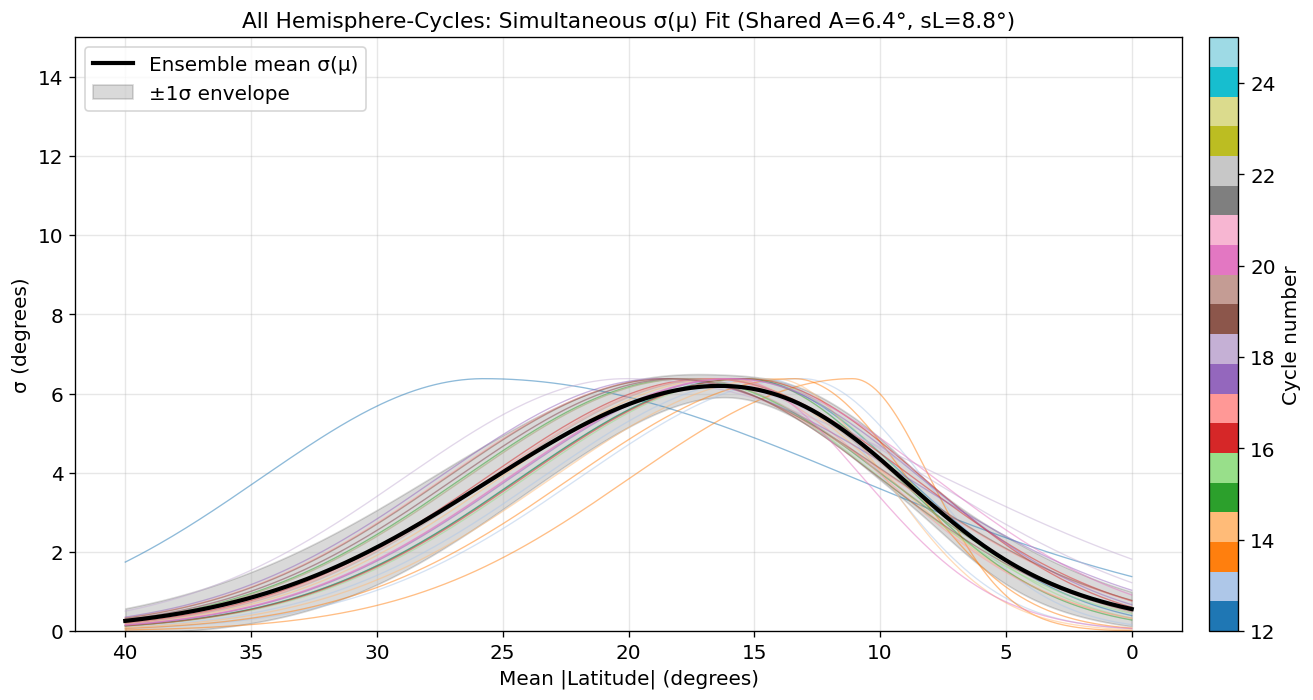

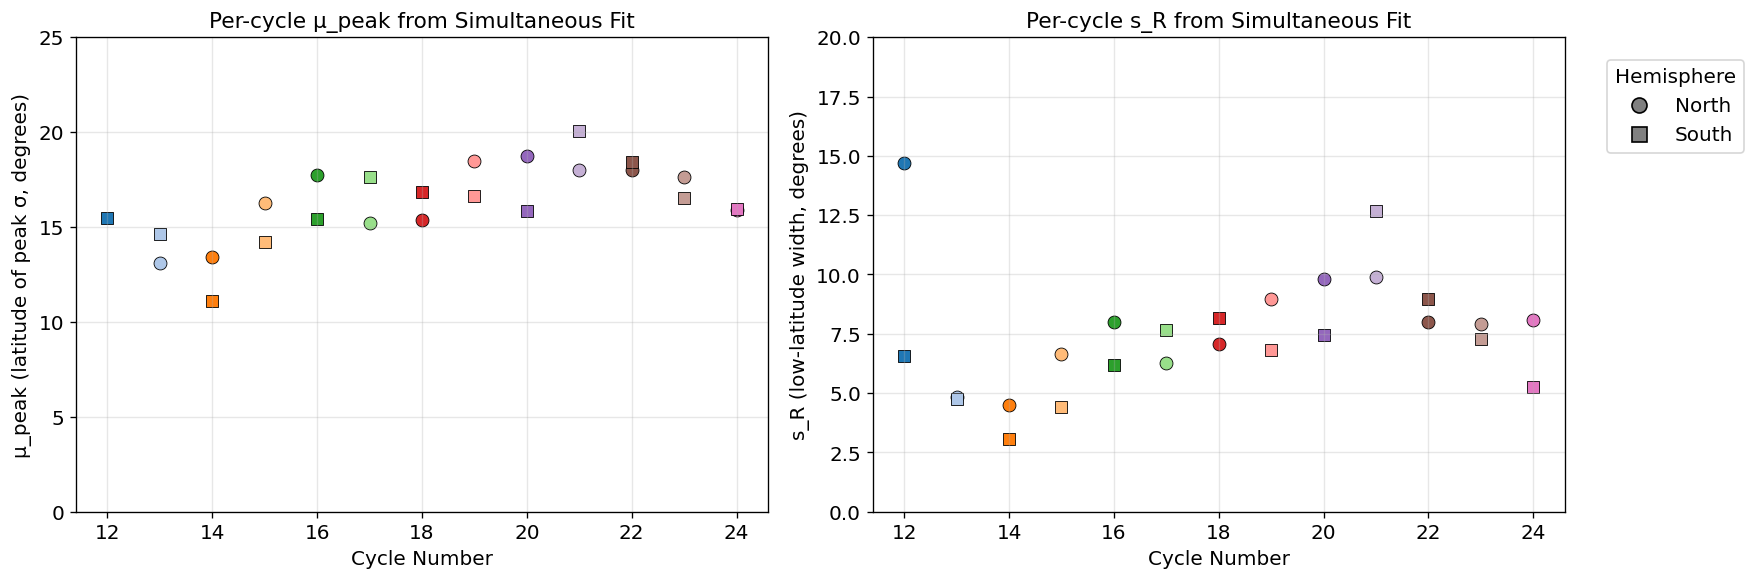

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import minimize
from matplotlib.lines import Line2D

# Re-define split_normal_mu function to ensure it's available in this cell's context
def split_normal_mu(mu, A, mu_peak, s_L, s_R, mu_peak_fixed=None):
    _mu_peak = mu_peak_fixed if mu_peak_fixed is not None else mu_peak
    # Mu is inverted on the x-axis for plotting, so 'left' means higher latitude (mu > mu_peak)
    # The function definition must account for this, ensuring s_L relates to the higher latitude side
    return np.where(mu > _mu_peak,
                    A * np.exp(-0.5 * ((mu - _mu_peak) / s_L) ** 2), # This is the high-latitude side
                    A * np.exp(-0.5 * ((mu - _mu_peak) / s_R) ** 2)) # This is the low-latitude side

# --- 1. Collect binned data and initial guesses for all hemisphere-cycles ---
# We'll use the data stored in `ensemble_sigma_results` from Task 15

binned_data_for_simultaneous_fit = []

# Initial guess for shared A and s_L (using ensemble means from Task 15 summary for A_sn_mu and sL_sn_mu)
# Note: This uses the average of the *fitted individual parameters*, which is a good starting point.
initial_A_global = np.mean([r["A_sn_mu"] for r in ensemble_sigma_results])
initial_sL_global = np.mean([r["sL_sn_mu"] for r in ensemble_sigma_results])

# Fallback if `ensemble_sigma_results` is empty or not yet run
if np.isnan(initial_A_global):
    initial_A_global = 6.0
if np.isnan(initial_sL_global):
    initial_sL_global = 10.0


# Collect data and per-cycle initial guesses (mu_peak, s_R)
per_cycle_initial_guesses = []

for r in ensemble_sigma_results:
    binned_data_for_simultaneous_fit.append({
        "cycle": r["cycle"],
        "hemisphere": r["hemisphere"],
        "bin_mu": r["bin_mu"],
        "bin_sigma": r["bin_sigma"],
        "initial_A": r["A_sn_mu"],       # Store individual fit A for reference
        "initial_mu_peak": r["mu_peak_sn_mu"],
        "initial_sL": r["sL_sn_mu"],     # Store individual fit sL for reference
        "initial_sR": r["sR_sn_mu"]
    })
    per_cycle_initial_guesses.extend([r["mu_peak_sn_mu"], r["sR_sn_mu"]])

# Combine initial guesses into a single vector
initial_guesses = [initial_A_global, initial_sL_global] + per_cycle_initial_guesses

# --- 2. Define the residual function ---
def residual_function(params, data_list):
    shared_A = params[0]
    shared_sL = params[1]

    # The remaining parameters are per-cycle (mu_peak, s_R)
    per_cycle_params = params[2:]

    total_squared_residuals = 0.0
    param_idx = 0
    num_data_points_simultaneous = 0

    for data_item in data_list:
        mu_peak_local = per_cycle_params[param_idx]
        sR_local = per_cycle_params[param_idx + 1]

        # Use shared A and sL, and local mu_peak and sR
        model_sigma = split_normal_mu(data_item["bin_mu"], shared_A, mu_peak_local, shared_sL, sR_local)

        residuals = data_item["bin_sigma"] - model_sigma
        total_squared_residuals += np.sum(residuals**2)
        num_data_points_simultaneous += len(data_item["bin_mu"])

        param_idx += 2 # Move to the next cycle's mu_peak and sR

    return total_squared_residuals

# --- 3. Define bounds for parameters ---
# Bounds for shared_A: [0.1, 15.0]
# Bounds for shared_sL: [0.1, 30.0]

# Bounds for per-cycle mu_peak: [0.0, 45.0]
# Bounds for per-cycle s_R: [0.1, 30.0]

bounds = [(0.1, 15.0), (0.1, 30.0)] # Shared A, shared sL

for data_item in binned_data_for_simultaneous_fit:
    # Dynamic bounds for mu_peak based on observed bin_mu range for this cycle
    mu_min = data_item["bin_mu"].min()
    mu_max = data_item["bin_mu"].max()
    bounds.append((max(0.1, mu_min - 5), min(45.0, mu_max + 5))) # mu_peak
    bounds.append((0.1, 30.0)) # s_R

# --- 4. Perform the optimization ---
print(f"Starting simultaneous fit for {len(binned_data_for_simultaneous_fit)} hemisphere-cycles...")
print(f"Total parameters to fit: {len(initial_guesses)}")

try:
    # Using 'L-BFGS-B' for bound constraints and potentially large number of parameters
    res = minimize(residual_function, initial_guesses, args=(binned_data_for_simultaneous_fit,),
                   method='L-BFGS-B', bounds=bounds, options={'maxiter': 5000})

    fitted_params = res.x
    shared_A_fit = fitted_params[0]
    shared_sL_fit = fitted_params[1]
    per_cycle_fitted_params = fitted_params[2:]

    print("\nSimultaneous fit successful!")
    print(f"  Shared A (peak sigma amplitude): {shared_A_fit:.2f}°")
    print(f"  Shared sL (high-latitude Gaussian width): {shared_sL_fit:.2f}°")

    # Calculate RMSE for the simultaneous fit
    total_squared_residuals_simultaneous = residual_function(fitted_params, binned_data_for_simultaneous_fit)

    num_data_points_simultaneous = 0
    for data_item in binned_data_for_simultaneous_fit:
        num_data_points_simultaneous += len(data_item["bin_mu"])

    rmse_simultaneous = np.sqrt(total_squared_residuals_simultaneous / num_data_points_simultaneous)
    print(f"  RMSE of simultaneous fit: {rmse_simultaneous:.3f}°")

except Exception as e:
    print(f"\nSimultaneous fit failed: {e}")
    fitted_params = np.array(initial_guesses) # Fallback to initial guesses if fit fails
    shared_A_fit = initial_A_global
    shared_sL_fit = initial_sL_global
    per_cycle_fitted_params = np.array(per_cycle_initial_guesses)
    rmse_simultaneous = np.nan


# --- 5. Prepare results for plotting ---
SIMULTANEOUS_FIT_MU_GRID = np.linspace(0, 40, 300) # Common μ grid

simultaneous_fit_results = []
param_idx = 0
for data_item in binned_data_for_simultaneous_fit:
    mu_peak_local = per_cycle_fitted_params[param_idx]
    sR_local = per_cycle_fitted_params[param_idx + 1]

    sigma_curve_evaluated = split_normal_mu(SIMULTANEOUS_FIT_MU_GRID, shared_A_fit, mu_peak_local, shared_sL_fit, sR_local)

    simultaneous_fit_results.append(dict(
        cycle=data_item["cycle"],
        hemisphere=data_item["hemisphere"],
        mu_peak=mu_peak_local,
        sR=sR_local,
        sigma_curve=sigma_curve_evaluated
    ))
    param_idx += 2


# --- 6. Plot the fitted curves ---
fig, ax = plt.subplots(figsize=(12, 6))

cmap_ens = plt.colormaps["tab20"]
cycle_idx_map = {c: i for i, c in enumerate(cycles_to_fit)} # `cycles_to_fit` from Task 15

for r in simultaneous_fit_results:
    ax.plot(SIMULTANEOUS_FIT_MU_GRID, r["sigma_curve"],
            color=cmap_ens(cycle_idx_map[r["cycle"]]), linewidth=0.8, alpha=0.5)

# Calculate and plot ensemble mean and std of the simultaneous fits
sigma_mat_simultaneous = np.array([r["sigma_curve"] for r in simultaneous_fit_results])
sigma_mean_simultaneous = np.nanmean(sigma_mat_simultaneous, axis=0)
sigma_std_simultaneous = np.nanstd(sigma_mat_simultaneous, axis=0)

ax.plot(SIMULTANEOUS_FIT_MU_GRID, sigma_mean_simultaneous, color="black", linewidth=2.5, label="Ensemble mean σ(μ)")
ax.fill_between(SIMULTANEOUS_FIT_MU_GRID, sigma_mean_simultaneous - sigma_std_simultaneous, sigma_mean_simultaneous + sigma_std_simultaneous,
                 color="black", alpha=0.15, label="±1σ envelope")

ax.set_xlabel("Mean |Latitude| (degrees)")
ax.set_ylabel("σ (degrees)")
ax.set_title(f"All Hemisphere-Cycles: Simultaneous σ(μ) Fit (Shared A={shared_A_fit:.1f}°, sL={shared_sL_fit:.1f}°)")
ax.set_ylim(0, 15) # Standard range for sigma
ax.invert_xaxis() # Reverse x-axis so high latitude is on the left
ax.legend(loc="upper left")

# Add colorbar for cycle numbers
sm = plt.cm.ScalarMappable(cmap="tab20",
                            norm=plt.Normalize(vmin=min(cycles_to_fit),
                                               vmax=max(cycles_to_fit)))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Cycle number")

plt.tight_layout()
plt.show()


# --- 7. Plot the per-cycle μ_peak and s_R parameters ---
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

markers = {"north": "o", "south": "s"}

# Plot μ_peak
ax_mu_peak_sim = axs[0]
for r in simultaneous_fit_results:
    ax_mu_peak_sim.scatter(r["cycle"], r["mu_peak"],
                           color=cmap_ens(cycle_idx_map[r["cycle"]]),
                           marker=markers[r["hemisphere"]],
                           s=60, edgecolors="black", linewidths=0.5)
ax_mu_peak_sim.set_xlabel("Cycle Number")
ax_mu_peak_sim.set_ylabel("μ_peak (latitude of peak σ, degrees)")
ax_mu_peak_sim.set_title("Per-cycle μ_peak from Simultaneous Fit")
ax_mu_peak_sim.set_ylim(0, 25)

# Plot s_R
ax_sR_sim = axs[1]
for r in simultaneous_fit_results:
    ax_sR_sim.scatter(r["cycle"], r["sR"],
                      color=cmap_ens(cycle_idx_map[r["cycle"]]),
                      marker=markers[r["hemisphere"]],
                      s=60, edgecolors="black", linewidths=0.5)
ax_sR_sim.set_xlabel("Cycle Number")
ax_sR_sim.set_ylabel("s_R (low-latitude width, degrees)")
ax_sR_sim.set_title("Per-cycle s_R from Simultaneous Fit")
ax_sR_sim.set_ylim(0, 20)

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markersize=9,
           label="North", markeredgecolor="black"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="gray", markersize=9,
           label="South", markeredgecolor="black"),
]
fig.legend(handles=legend_handles, title="Hemisphere", loc="upper right", bbox_to_anchor=(1.05, 0.9))

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()